# RETECO Track 1a — Thí nghiệm tầng một (CPU)
# RETECO Track 1a — First-stage experiments (CPU only)

**VI** — Notebook này trả lời ba câu hỏi bằng **đo đạc**, không bằng suy đoán, và cả ba đều chạy được **hoàn toàn trên CPU**. Mục đích là chốt xong mọi quyết định *không thể đảo ngược* trước khi tiêu một phút GPU nào.

**EN** — This notebook settles three questions by **measurement**, not argument, and all three run **entirely on CPU**. Its purpose is to close every *irreversible* decision before a single minute of GPU time is spent.

## Vì sao phải làm trước khi dùng GPU · Why this comes before the GPU

**VI** — Embedding cache của hệ thống được khoá theo bốn thứ: **model**, **độ dài cắt tài liệu**, **chính corpus**, và **passage prefix**. Đổi bất kỳ thứ nào trong bốn → phải encode lại toàn bộ 1,65 triệu tài liệu. Mọi thứ còn lại (query form, trọng số fusion, số ứng viên rerank, top-k) đều sweep được trên CPU với cache đã có.

Nói cách khác: **GPU dùng để mua cái cache, không phải để chạy thí nghiệm.** Notebook này chốt hai trong bốn quyết định đó (corpus, và tokenizer ảnh hưởng tới tầng lexical), đồng thời đo trần recall — con số quyết định việc rerank có đáng đầu tư hay không.

**EN** — The embedding cache is keyed on four things: **model**, **document truncation length**, **the corpus itself**, and **passage prefix**. Changing any one forces a full re-encode of all 1.65M documents. Everything else sweeps on CPU against an existing cache. So: **the GPU buys the cache, not the experiments.**

## Ba câu hỏi · The three questions

| # | Câu hỏi · Question | Vì sao quan trọng · Why it matters |
| --- | --- | --- |
| 1 | BM25 của ta đạt macro nDCG@10 = 0,0719 trong khi baseline chính thức là 0,0879. Khoảng cách 22% đó từ đâu ra? | Nếu nguyên nhân là **tokenization**, đây là điểm sửa rẻ nhất trong toàn hệ thống — không cần GPU, không cần đổi kiến trúc. |
| 2 | Bốn cách dựng truy vấn khác nhau cho recall bao nhiêu? Trần recall của tầng một ở đâu? | **Rerank không bao giờ vượt được trần recall của tầng một.** Nếu trần là 12%, đổi model rerank là vô nghĩa. |
| 3 | Khử trùng lặp corpus giúp hay hại? | Corpus nằm trong cache key → đây là quyết định **không đảo ngược được** sau khi encode. |

## Nguyên tắc đọc kết quả · How to read every number here

**VI** — Một kết luận trong notebook này chỉ được phát biểu khi nó vượt **ngưỡng nhiễu**. Đo bằng bootstrap trên chính bộ dữ liệu này:

| Số truy vấn | Khoảng tin cậy 95% cho chênh lệch ngẫu nhiên |
| --- | --- |
| 7 (một domain nhỏ) | ±0,429 |
| 58 (một domain trung bình) | ±0,207 |
| 1.211 (gộp cả 13 domain) | **±0,045** |

**Hệ quả: không kết luận gì từ một domain lẻ.** Mọi so sánh dưới đây đều gộp per-query trên cả 13 domain rồi mới lấy khoảng tin cậy.

**EN** — A finding is only stated here if it clears the **noise floor**, measured by bootstrap on this dataset. A single small domain has a ±0.429 confidence interval; pooling all 1,211 queries brings it to ±0.045. **Nothing is concluded from one domain.**

> **Luật cuộc thi · Competition rule** — Mọi thứ trong notebook này chạy trên **`train`**. Split `dev` chỉ được dùng **đúng một lần**, ở cuối cùng, như kiểm tra held-out. · Everything here runs on `train`; `dev` is touched once, at the very end.

---

# Phần A · Part A — Thiết lập · Setup

**VI** — Notebook này **tự chứa**: nó cài đặt lại BM25, metric và tokenizer từ đầu thay vì import `src/track1a/`. Đó là chủ ý. Nếu nó import chính đoạn mã đang cần kiểm chứng thì câu "ta tái lập được baseline" trở thành lập luận vòng tròn. Phần B sẽ chứng minh bản cài đặt độc lập này cho ra **đúng cùng xếp hạng** với hệ thống production.

**EN** — This notebook is **self-contained**: it reimplements BM25, the metrics and the tokenizer rather than importing `src/track1a/`. That is deliberate — importing the very code under test would make "we reproduced the baseline" circular. Part B proves this independent implementation produces **identical rankings** to the production system.

**VI** — Chi phí bị chi phối bởi **số lần tokenize toàn bộ corpus**. Một lượt quét đủ 13 domain (1,65 triệu tài liệu) mất khoảng **7 phút**, đo bằng cách nhân tỉ lệ từ corpus thật. Vì vậy mỗi phần dưới đây tokenize **đúng một lượt mỗi domain** rồi tái sử dụng cho mọi cấu hình bên trong nó:

| Phần | Số lượt quét | Thời gian ước tính | Đỉnh RAM |
| --- | --- | --- | --- |
| B — tái lập baseline | 1 | ~7 phút | ~2,9 GB (ở domain lớn nhất) |
| C — 6 biến thể tokenizer | 1 | ~12 phút | ~2,9 GB |
| D — 4 dạng truy vấn | 1 | ~10 phút | ~2,9 GB |
| D.1 — tương tác (3×3) | 1 | ~12 phút | ~2,9 GB |
| E — 4 chính sách khử trùng lặp | 1 | ~12 phút | ~2,9 GB |

Tổng khoảng **50 phút** cho cả 13 domain. Mỗi domain được nạp, dùng, rồi **giải phóng** trước khi sang domain kế — không bao giờ giữ hai domain trong RAM cùng lúc.

### Phần nào phụ thuộc phần nào · What depends on what

| Phần | Cần chạy trước | |
| --- | --- | --- |
| B, C, D, E | chỉ cần **A** | chạy riêng lẻ được |
| D.1 (tương tác) | **A + C + D** | vì nó ghép kết quả của cả hai |
| F (quyết định) | **A + C + D + D.1 + E** | vì nó tổng hợp tất cả |

**EN** — Cost is dominated by how many times the corpus is tokenized; one full pass over all 13 domains takes about 7 minutes, so every part below tokenizes **once per domain** and reuses it for every configuration inside that part (~50 minutes total). Parts B, C, D and E each need only Part A; the interaction cell needs C and D; Part F needs all of them.

In [1]:
# --- Configuration -------------------------------------------------------
import os, sys, json, re, gc, time, hashlib, platform
from pathlib import Path
from collections import Counter, defaultdict
from array import array
from math import log2

import numpy as np
from scipy import sparse
import matplotlib
import matplotlib.pyplot as plt

# Locate the RETECO release: walk up from the notebook looking for the
# track1_tempo directory, so this works from notebooks/ or the project root.
def find_data_root(start=None):
    here = Path(start or os.getcwd()).resolve()
    for base in [here, *here.parents]:
        cand = base / "reteco_data" / "track1_tempo"
        if cand.is_dir():
            return cand
    raise FileNotFoundError(
        "Could not find reteco_data/track1_tempo. Set TRACK1_ROOT manually."
    )

TRACK1_ROOT = find_data_root()
SPLIT       = "train"          # competition rule: tune on train only
RESULTS_DIR = Path.cwd() / "results_nb02"
RESULTS_DIR.mkdir(exist_ok=True)

# None -> every domain. Set a short list for a fast smoke test.
DOMAINS = None
# None -> whole corpus. Set e.g. 5000 for a fast smoke test.
MAX_DOCS_PER_DOMAIN = None

K1, B_PARAM = 0.9, 0.4         # same BM25 parameters as the starter kit
TOP_K       = 1000             # deep enough to measure the recall ceiling
RECALL_KS   = (10, 100, 1000)

# Reference points this notebook is measured against.
OUR_BM25_MACRO      = 0.0719   # our current 13-domain macro nDCG@10
OFFICIAL_BM25_MACRO = 0.0879   # the organizers' published BM25 baseline

# The 13 Track 1 domains of the real release. Used only so the notebook can
# tell you when it is NOT looking at the full release, rather than silently
# comparing a subset against a 13-domain reference number.
EXPECTED_DOMAINS = {"bitcoin", "cardano", "economics", "genealogy", "history",
                    "hsm", "iota", "law", "monero", "politics", "quant",
                    "travel", "workplace"}

ALL_DOMAINS = sorted(p.name for p in TRACK1_ROOT.iterdir() if p.is_dir())
IS_FULL_RELEASE = set(ALL_DOMAINS) == EXPECTED_DOMAINS
DOMAINS_TO_RUN = DOMAINS or ALL_DOMAINS

print(f"python      {platform.python_version()}   numpy {np.__version__}   scipy {sparse.__version__ if hasattr(sparse,'__version__') else ''}")
print(f"data root   {TRACK1_ROOT}")
print(f"split       {SPLIT}")
print(f"domains     {len(DOMAINS_TO_RUN)} -> {', '.join(DOMAINS_TO_RUN)}")
print(f"results     {RESULTS_DIR}")
if not IS_FULL_RELEASE:
    print(f"\n[!] This is NOT the full 13-domain release "
          f"(found {len(ALL_DOMAINS)}: {', '.join(ALL_DOMAINS)}).")
    print( "    Reference numbers (0.0719 / 0.0879) are 13-domain macro averages,")
    print( "    so the Part B gate will be reported as not applicable.")
if MAX_DOCS_PER_DOMAIN:
    print(f"\n*** SMOKE TEST MODE: corpus truncated to {MAX_DOCS_PER_DOMAIN:,} docs/domain ***")
    print("*** Numbers below are NOT comparable to the real baseline.        ***")

python      3.13.5   numpy 2.2.6   scipy 
data root   D:\RETECO-project\reteco_data\track1_tempo
split       train
domains     13 -> bitcoin, cardano, economics, genealogy, history, hsm, iota, law, monero, politics, quant, travel, workplace
results     d:\RETECO-project\notebooks\results_nb02


In [2]:
# --- Chart style ---------------------------------------------------------
# One palette for the whole notebook, so a colour always means the same thing.
SURFACE   = "#fcfcfb"
INK       = "#0b0b0b"
INK_SOFT  = "#52514e"
GRID      = "#e1e0d9"
AXIS      = "#c3c2b7"
SERIES    = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
MUTED     = "#b9b8ae"

plt.rcParams.update({
    "figure.facecolor":  SURFACE,
    "axes.facecolor":    SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor":    AXIS,
    "axes.labelcolor":   INK_SOFT,
    "axes.titlecolor":   INK,
    "xtick.color":       INK_SOFT,
    "ytick.color":       INK_SOFT,
    "text.color":        INK,
    "grid.color":        GRID,
    "grid.linewidth":    0.8,
    "axes.linewidth":    0.8,
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.titlepad":     14,
    "figure.dpi":        110,
})

def style_axes(ax, xgrid=False, ygrid=True):
    """Hairline, solid grid on one axis only; no box around the plot.

    Line properties are only passed when the grid is actually being turned on:
    matplotlib warns (and silently enables the grid) if styling is supplied
    alongside visible=False.
    """
    ax.set_axisbelow(True)
    for axis, on in (("y", ygrid), ("x", xgrid)):
        if on:
            ax.grid(axis=axis, visible=True, linestyle="-", linewidth=0.8, color=GRID)
        else:
            ax.grid(axis=axis, visible=False)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    return ax

print("chart style ready")

chart style ready


### A.1 — Metric: bản sao chính xác của scorer chính thức · An exact replica of the official scorer

**VI** — Đoạn mã dưới cài lại `ir_metrics.py` và `scorer.py` của ban tổ chức. Có **một chi tiết** trong scorer chính thức phải sao chép nguyên vẹn vì nó có thể làm sai lệch mọi so sánh:

> `scorer.py` chỉ chấm những truy vấn **có mặt trong file run**: `qids = [q for q in gold if q in run]`.

**Một truy vấn không trả về gì sẽ bị *loại khỏi mẫu*, chứ không bị chấm 0 điểm.** Nghĩa là một biến thể tokenizer quá mạnh tay — xoá sạch từ khoá của vài truy vấn khiến chúng không khớp tài liệu nào — sẽ **trông có vẻ tốt hơn**, vì những truy vấn khó nhất bị âm thầm rút khỏi phép tính trung bình.

Vì vậy **mọi bảng kết quả trong notebook này đều in `num_topics` cạnh điểm số.** Nếu `num_topics` tụt xuống, điểm số đó không so sánh được.

**EN** — This replicates the organizers' scorer, including one subtlety that must be copied exactly: `scorer.py` scores only queries present in the run file. **A query that retrieves nothing is dropped from the average, not scored zero** — so an over-aggressive tokenizer that wipes out a query's terms would look *better*, because the hardest queries silently leave the sample. Every table below therefore prints `num_topics` beside the score.

In [3]:
# --- Official metrics (exact replica of RETECO/starter_kit/ir_metrics.py) --
def _dcg(rels):
    return sum(r / log2(i + 2) for i, r in enumerate(rels))

def ndcg_at_k(ranked, gold, k=10):
    """Binary nDCG@k: gold is a set of relevant doc ids, each of grade 1."""
    grades = [1.0 if d in gold else 0.0 for d in ranked[:k]]
    idcg = _dcg([1.0] * min(len(gold), k))
    return (_dcg(grades) / idcg) if idcg > 0 else 0.0

def temporal_relevance_at_k(ranked, gold, k=10):
    top = ranked[:k]
    return (sum(1 for d in top if d in gold) / len(top)) if top else 0.0

def temporal_precision_at_k(ranked, gold, k=10):
    num = den = 0.0
    for i, d in enumerate(ranked[:k]):
        w = 1.0 / log2(i + 2)
        den += w
        if d in gold:
            num += w
    return (num / den) if den > 0 else 0.0

def temporal_coverage_at_k(ranked, period_gold, k=10):
    if not period_gold:
        return None
    top = set(ranked[:k])
    return sum(1 for gs in period_gold if top & set(gs)) / len(period_gold)

def recall_at_k(ranked, gold, k):
    return (len(set(ranked[:k]) & set(gold)) / len(gold)) if gold else None

def mean(xs):
    xs = [x for x in xs if x is not None]
    return (sum(xs) / len(xs)) if xs else 0.0

def score_domain(run, gold, periods=None, k=10, recall_ks=RECALL_KS):
    """Score one domain exactly as the official scorer does.

    Deliberately replicated: only queries present in BOTH gold and run are
    scored. num_topics is returned so a shrinking sample can never hide.
    """
    periods = periods or {}
    qids = [q for q in gold if q in run]
    nd = [ndcg_at_k(run[q], gold[q], k) for q in qids]
    tcs = [temporal_coverage_at_k(run[q], periods.get(q, []), k) for q in qids]
    out = {
        "num_topics": len(qids),
        "num_gold_topics": len(gold),
        f"nDCG@{k}": mean(nd),
        f"TP@{k}": mean([temporal_precision_at_k(run[q], gold[q], k) for q in qids]),
        f"TR@{k}": mean([temporal_relevance_at_k(run[q], gold[q], k) for q in qids]),
        f"TC@{k}": mean(tcs),
        "num_full_coverage": sum(1 for t in tcs if t == 1.0),
    }
    for rk in recall_ks:
        out[f"R@{rk}"] = mean([recall_at_k(run[q], gold[q], rk) for q in qids])
    # Per-query scores are kept: pooled confidence intervals need them.
    out["per_query_ndcg"] = {q: n for q, n in zip(qids, nd)}
    out["per_query_recall"] = {
        f"R@{rk}": {q: recall_at_k(run[q], gold[q], rk) for q in qids}
        for rk in recall_ks
    }
    return out

def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=0):
    """Percentile bootstrap CI for a mean. A difference smaller than this
    interval is indistinguishable from resampling noise."""
    v = np.asarray([x for x in values if x is not None], dtype=np.float64)
    if v.size == 0:
        return 0.0, 0.0, 0.0
    rng = np.random.default_rng(seed)
    means = rng.choice(v, size=(n_boot, v.size), replace=True).mean(axis=1)
    lo, hi = np.percentile(means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(v.mean()), float(lo), float(hi)

# --- self-test: hand-computable cases ------------------------------------
_g = {"a", "b"}
assert abs(ndcg_at_k(["a", "b"], _g, 10) - 1.0) < 1e-12
assert ndcg_at_k(["x", "y"], _g, 10) == 0.0
# one gold at rank 1 of 2 gold: DCG=1, IDCG=1+1/log2(3)
assert abs(ndcg_at_k(["a", "x"], _g, 10) - 1.0 / (1 + 1 / log2(3))) < 1e-12
# gold at rank 2 is discounted by 1/log2(3)
assert abs(ndcg_at_k(["x", "a"], _g, 10) - (1 / log2(3)) / (1 + 1 / log2(3))) < 1e-12
assert recall_at_k(["a", "x", "y"], _g, 3) == 0.5
assert temporal_coverage_at_k(["a"], [{"a"}, {"z"}], 10) == 0.5
print("metric self-test passed")

metric self-test passed


### A.2 — Nạp dữ liệu và bốn dạng truy vấn · Loaders and the four query forms

**VI** — Truy vấn trong bộ dữ liệu này là **nguyên một bài đăng Stack Exchange**: tiêu đề ngắn rồi tới thân bài dài hơn nhiều. Đo trên release: thân dài gấp **4,8–18,0 lần** tiêu đề, và **100% truy vấn mang thẻ HTML** trong khi tài liệu gần như không có thẻ nào. Bốn dạng dưới đây tách riêng hai yếu tố đó — độ dài thân bài, và nhiễu HTML — để Phần D đo được cái nào thực sự gây hại.

**EN** — Queries here are whole Stack Exchange posts: a short title then a much longer body (4.8–18.0x the title), and 100% carry HTML markup that the documents do not. The four forms below separate those two factors so Part D can measure which one actually hurts.

In [4]:
# --- Loading -------------------------------------------------------------
def load_corpus(path, limit=None):
    ids, texts = [], []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                d = json.loads(line)
                ids.append(d["id"]); texts.append(d["content"])
                if limit and len(ids) >= limit:
                    break
    return ids, texts

def load_queries(path):
    with open(path, "r", encoding="utf-8") as f:
        return [(d["id"], d["query"])
                for d in (json.loads(l) for l in f if l.strip())]

def load_qrels(path):
    gold = defaultdict(set)
    with open(path, "r", encoding="utf-8") as f:
        for ln in f:
            if ln.strip():
                qid, _, docid, rel = ln.split()
                if int(rel) > 0:
                    gold[qid].add(docid)
    return dict(gold)

def load_steps(path):
    periods = {}
    with open(path, "r", encoding="utf-8") as f:
        for ln in f:
            if ln.strip():
                rec = json.loads(ln)
                periods[rec["id"]] = [set(st.get("gold_ids", []))
                                      for st in rec.get("steps", [])]
    return periods

def domain_files(domain, split=SPLIT):
    d = TRACK1_ROOT / domain
    return {"corpus": d / "documents.jsonl",
            "queries": d / f"examples_{split}.jsonl",
            "qrels":   d / f"qrels_{split}.txt",
            "steps":   d / f"steps_{split}.jsonl"}

# --- Query forms ---------------------------------------------------------
_HTML_TAG    = re.compile(r"<[^>]+>")
_HTML_ENTITY = re.compile(r"&(quot|amp|lt|gt|nbsp|#\d+);")

def strip_markup(text):
    text = _HTML_TAG.sub(" ", text)
    text = _HTML_ENTITY.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()

def title_of(query):
    """The title is everything before the first <p>; the rest is the body."""
    m = re.search(r"<p>", query)
    return query[:m.start()] if m else query

QUERY_FORMS = {
    "raw":            lambda q: q,                                        # as published
    "stripped":       lambda q: strip_markup(q),                          # markup removed
    "title":          lambda q: strip_markup(title_of(q)),                # title only
    "title-weighted": lambda q: strip_markup((title_of(q) + " ") * 3 + q),# title up-weighted
}

_demo = "How long do Zero Value Transactions last?\n<p>Let s say we have some data &amp; more.</p>"
for _n, _f in QUERY_FORMS.items():
    print(f"  {_n:<15} {len(_f(_demo)):>4} chars  {_f(_demo)[:58]!r}")

  raw               88 chars  'How long do Zero Value Transactions last?\n<p>Let s say we '
  stripped          75 chars  'How long do Zero Value Transactions last? Let s say we hav'
  title             41 chars  'How long do Zero Value Transactions last?'
  title-weighted   201 chars  'How long do Zero Value Transactions last? How long do Zero'


### A.3 — Porter stemmer (tự chứa) · Porter stemmer (self-contained)

**VI** — `nltk` không được giả định là đã cài, nên thuật toán Porter (1980) được cài lại ở đây. Ô kiểm thử ngay sau đó đối chiếu với **chính các ví dụ Porter công bố** cho từng bước của thuật toán — 75 cặp từ, phủ cả bảy bước. Nếu ô đó báo lỗi thì mọi kết luận ở Phần C đều vô hiệu.

**EN** — `nltk` is not assumed present, so Porter (1980) is implemented here. The test cell below checks it against **Porter's own published examples** for every step of the algorithm — 75 word pairs covering all seven steps. If that cell fails, every conclusion in Part C is void.

In [5]:
class PorterStemmer:
    """Porter (1980) suffix stripping. Memoised: the vocabulary is ~10^5 terms
    against ~10^8 tokens, so stemming the VOCABULARY rather than the token
    stream is what makes the Part C sweep affordable."""

    def __init__(self):
        self._cache = {}

    @staticmethod
    def _is_cons(w, i):
        c = w[i]
        if c in "aeiou":
            return False
        if c == "y":
            return True if i == 0 else not PorterStemmer._is_cons(w, i - 1)
        return True

    @classmethod
    def _m(cls, w):
        """Measure: number of vowel-consonant sequences."""
        n, i, L = 0, 0, len(w)
        while i < L and cls._is_cons(w, i):
            i += 1
        while i < L:
            while i < L and not cls._is_cons(w, i):
                i += 1
            if i >= L:
                break
            n += 1
            while i < L and cls._is_cons(w, i):
                i += 1
        return n

    @classmethod
    def _has_vowel(cls, w):
        return any(not cls._is_cons(w, i) for i in range(len(w)))

    @classmethod
    def _double_cons_end(cls, w):
        return len(w) >= 2 and w[-1] == w[-2] and cls._is_cons(w, len(w) - 1)

    @classmethod
    def _cvc(cls, w):
        if len(w) < 3:
            return False
        if not (cls._is_cons(w, len(w) - 1) and not cls._is_cons(w, len(w) - 2)
                and cls._is_cons(w, len(w) - 3)):
            return False
        return w[-1] not in "wxy"

    def _step1ab(self, w):
        if w.endswith("sses"):   w = w[:-2]
        elif w.endswith("ies"):  w = w[:-2]
        elif w.endswith("ss"):   pass
        elif w.endswith("s"):    w = w[:-1]

        if w.endswith("eed"):
            if self._m(w[:-3]) > 0:
                w = w[:-1]
        elif w.endswith("ed") and self._has_vowel(w[:-2]):
            w = self._step1b_tail(w[:-2])
        elif w.endswith("ing") and self._has_vowel(w[:-3]):
            w = self._step1b_tail(w[:-3])
        return w

    def _step1b_tail(self, s):
        if s.endswith(("at", "bl", "iz")):
            return s + "e"
        if self._double_cons_end(s) and not s.endswith(("l", "s", "z")):
            return s[:-1]
        if self._m(s) == 1 and self._cvc(s):
            return s + "e"
        return s

    def _step1c(self, w):
        return w[:-1] + "i" if w.endswith("y") and self._has_vowel(w[:-1]) else w

    _STEP2 = [("ational","ate"),("tional","tion"),("enci","ence"),("anci","ance"),
              ("izer","ize"),("abli","able"),("alli","al"),("entli","ent"),
              ("eli","e"),("ousli","ous"),("ization","ize"),("ation","ate"),
              ("ator","ate"),("alism","al"),("iveness","ive"),("fulness","ful"),
              ("ousness","ous"),("aliti","al"),("iviti","ive"),("biliti","ble")]
    _STEP3 = [("icate","ic"),("ative",""),("alize","al"),("iciti","ic"),
              ("ical","ic"),("ful",""),("ness","")]
    _STEP4 = ["al","ance","ence","er","ic","able","ible","ant","ement","ment",
              "ent","ou","ism","ate","iti","ous","ive","ize"]

    def _apply(self, w, table, min_m=0):
        for suf, rep in table:
            if w.endswith(suf):
                stem = w[:-len(suf)]
                return stem + rep if self._m(stem) > min_m else w
        return w

    def _step2(self, w): return self._apply(w, self._STEP2)
    def _step3(self, w): return self._apply(w, self._STEP3)

    def _step4(self, w):
        for suf in sorted(self._STEP4, key=len, reverse=True):
            if w.endswith(suf):
                stem = w[:-len(suf)]
                return stem if self._m(stem) > 1 else w
        if w.endswith("ion"):
            stem = w[:-3]
            if self._m(stem) > 1 and stem.endswith(("s", "t")):
                return stem
        return w

    def _step5(self, w):
        if w.endswith("e"):
            m = self._m(w[:-1])
            if m > 1 or (m == 1 and not self._cvc(w[:-1])):
                w = w[:-1]
        if self._m(w) > 1 and self._double_cons_end(w) and w.endswith("l"):
            w = w[:-1]
        return w

    def stem(self, word):
        hit = self._cache.get(word)
        if hit is not None:
            return hit
        w = word
        if len(w) > 2:
            for step in (self._step1ab, self._step1c, self._step2,
                         self._step3, self._step4, self._step5):
                w = step(w)
        self._cache[word] = w
        return w

STEMMER = PorterStemmer()   # one shared instance: the cache is reused across domains

In [6]:
# --- Stemmer validation against Porter's own published step examples ------
_VEC = {
 "1a": ([("caresses","caress"),("ponies","poni"),("ties","ti"),
         ("caress","caress"),("cats","cat")], "_step1ab"),
 "1b": ([("feed","feed"),("agreed","agree"),("plastered","plaster"),
         ("bled","bled"),("motoring","motor"),("sing","sing"),
         ("conflated","conflate"),("troubled","trouble"),("sized","size"),
         ("hopping","hop"),("tanned","tan"),("falling","fall"),
         ("hissing","hiss"),("fizzed","fizz"),("failing","fail"),
         ("filing","file")], "_step1ab"),
 "1c": ([("happy","happi"),("sky","sky")], "_step1c"),
 "2":  ([("relational","relate"),("conditional","condition"),("rational","rational"),
         ("valenci","valence"),("hesitanci","hesitance"),("digitizer","digitize"),
         ("conformabli","conformable"),("radicalli","radical"),
         ("differentli","different"),("vileli","vile"),("analogousli","analogous"),
         ("vietnamization","vietnamize"),("predication","predicate"),
         ("operator","operate"),("feudalism","feudal"),("decisiveness","decisive"),
         ("hopefulness","hopeful"),("callousness","callous"),("formaliti","formal"),
         ("sensitiviti","sensitive"),("sensibiliti","sensible")], "_step2"),
 "3":  ([("triplicate","triplic"),("formative","form"),("formalize","formal"),
         ("electriciti","electric"),("electrical","electric"),("hopeful","hope"),
         ("goodness","good")], "_step3"),
 "4":  ([("revival","reviv"),("allowance","allow"),("inference","infer"),
         ("airliner","airlin"),("gyroscopic","gyroscop"),("adjustable","adjust"),
         ("defensible","defens"),("irritant","irrit"),("replacement","replac"),
         ("adjustment","adjust"),("dependent","depend"),("adoption","adopt"),
         ("homologou","homolog"),("communism","commun"),("activate","activ"),
         ("angulariti","angular"),("homologous","homolog"),("effective","effect"),
         ("bowdlerize","bowdler")], "_step4"),
 "5":  ([("probate","probat"),("rate","rate"),("cease","ceas"),
         ("controll","control"),("roll","roll")], "_step5"),
}

_fail = 0
for _step, (_cases, _fn) in _VEC.items():
    _f = getattr(STEMMER, _fn)
    _bad = [(w, e, _f(w)) for w, e in _cases if _f(w) != e]
    print(f"  Porter step {_step:<3} {'OK  ' if not _bad else 'FAIL'} {len(_cases)-len(_bad)}/{len(_cases)}")
    for w, e, g in _bad:
        print(f"      {w!r}: expected {e!r}, got {g!r}")
    _fail += len(_bad)

# The property the experiment actually depends on: inflections must collapse.
for _grp in [["connect","connected","connecting","connection","connections"],
             ["transact","transaction","transactions","transactional"],
             ["compute","computed","computing","computation","computations"]]:
    _s = {STEMMER.stem(w) for w in _grp}
    assert len(_s) == 1, f"{_grp} did not collapse: {_s}"

assert _fail == 0, f"{_fail} Porter vectors failed -- Part C is not trustworthy"
print(f"\n  all {sum(len(c) for c,_ in _VEC.values())} published vectors pass; inflections collapse correctly")

  Porter step 1a  OK   5/5
  Porter step 1b  OK   16/16
  Porter step 1c  OK   2/2
  Porter step 2   OK   21/21
  Porter step 3   OK   7/7
  Porter step 4   OK   19/19
  Porter step 5   OK   5/5

  all 75 published vectors pass; inflections collapse correctly


### A.4 — Tokenize một lần, đổi tokenizer nhiều lần · Tokenize once, vary many times

**VI** — Đây là thủ thuật làm cho Phần C khả thi. Tokenize 1,65 triệu tài liệu là bước đắt nhất; bình thường mỗi biến thể tokenizer phải trả lại chi phí đó. Nhưng **mọi biến thể ở đây đều là hàm thuần của từng *từ*, không phụ thuộc tài liệu** — nên corpus được tokenize **một lần**, rồi mỗi biến thể chỉ là một phép **đánh số lại từ vựng** (~10⁵ từ, so với ~10⁸ token — rẻ hơn ba bậc độ lớn).

Hai chi tiết dễ sai, đều được kiểm thử ngay bên dưới:

1. **Hai từ gốc khác nhau rút về cùng một gốc thì số đếm phải *cộng lại*, không phải ghi đè.** `connect` (2 lần) + `connected` + `connecting` trong cùng một tài liệu phải thành `connect` = 4.
2. **Thứ tự lọc: bỏ stopword *trước*, rút gốc *sau*.** Làm ngược lại thì `this` bị rút thành `thi` và lọt qua danh sách stopword. Đây đúng là thứ tự của Lucene.

**EN** — The trick that makes Part C affordable: every variant here is a pure function of the *term*, so the corpus is tokenized once and each variant is a relabelling of the vocabulary — three orders of magnitude cheaper. Two easy mistakes, both tested below: counts of terms that collapse to one stem must be **added**, not overwritten; and stopwords must be removed **before** stemming, or `this` becomes `thi` and escapes the stop list.

In [7]:
_TOKEN = re.compile(r"[A-Za-z0-9]+")

def tokenize_raw(text):
    """The production tokenizer from src/track1a/retriever.py, verbatim."""
    return _TOKEN.findall((text or "").lower())

# Lucene's default English stop set (33 words) -- what Anserini/Pyserini strips
# by default, and therefore the leading hypothesis for the baseline gap.
LUCENE_STOPWORDS = frozenset("""
a an and are as at be but by for if in into is it no not of on or such
that the their then there these they this to was will with
""".split())

EXTENDED_STOPWORDS = LUCENE_STOPWORDS | frozenset("""
about above after again against all am been before being below between both
cannot did do does doing down during each few from further had has have
having he her here hers him his how i me more most my nor now only other
our out over own same she should so some than them themselves through too
under until up very we were what when where which while who whom why would
you your
""".split())

# HTML structural tokens. No English stop list removes these -- but 100% of
# queries carry markup and the documents carry none, so each is a query term
# that can only match noise.
HTML_TOKENS = frozenset("""
p br div span li ul ol a href http https www img src alt h1 h2 h3 h4 h5 h6
b i em strong code pre blockquote table tr td th hr sup sub nbsp quot amp lt
gt class id style rel nofollow target blank
""".split())

def apply_tokenizer(tokens, stopwords=frozenset(), stem=False, drop_html=False,
                    min_len=1, drop_pure_digits=False):
    """Apply a tokenizer variant to a token stream (used for QUERIES, and as
    the ground truth the vocabulary-remap route is checked against)."""
    out = []
    for t in tokens:
        if len(t) < min_len:                 continue
        if drop_pure_digits and t.isdigit(): continue
        if drop_html and t in HTML_TOKENS:   continue
        if t in stopwords:                   continue   # BEFORE stemming
        u = STEMMER.stem(t) if stem else t
        if u:
            out.append(u)
    return out

def build_vocab_map(terms, **kw):
    """Map each raw vocabulary term to a variant column, or -1 to drop it."""
    col_map = np.full(len(terms), -1, dtype=np.int64)
    new_ids, new_terms = {}, []
    for i, t in enumerate(terms):
        u = apply_tokenizer([t], **kw)
        if not u:
            continue
        u = u[0]
        j = new_ids.get(u)
        if j is None:
            j = len(new_terms); new_ids[u] = j; new_terms.append(u)
        col_map[i] = j
    return col_map, new_terms

def remap_counts(counts, col_map, n_new_terms):
    """Relabel the columns of a (docs x terms) count matrix.

    Rows are untouched by a vocabulary relabelling, so the new indptr follows
    from a running count of survivors and the CSR is rebuilt directly. Going
    via COO would materialise one row index per nonzero -- several hundred MB
    of pure overhead on the largest domain, and the measured memory peak of
    this notebook before it was removed.
    """
    new_col = col_map[counts.indices]
    keep = new_col >= 0
    new_indptr = np.concatenate(([0], np.cumsum(keep, dtype=np.int64)))[counts.indptr]
    out = sparse.csr_matrix(
        (counts.data[keep], new_col[keep].astype(np.int32, copy=False), new_indptr),
        shape=(counts.shape[0], max(n_new_terms, 1)))
    del new_col, keep, new_indptr
    out.sum_duplicates()          # terms sharing a stem have their counts ADDED
    return out

def tokenize_corpus(doc_texts, verbose=False):
    """One pass over the corpus -> (raw count matrix, raw vocabulary)."""
    vocab = {}
    indptr = array("q", [0]); indices = array("i"); data = array("f")
    for n, text in enumerate(doc_texts):
        counts = {}
        for t in tokenize_raw(text):
            counts[t] = counts.get(t, 0) + 1
        for t, f in counts.items():
            j = vocab.get(t)
            if j is None:
                j = len(vocab); vocab[t] = j
            indices.append(j); data.append(f)
        indptr.append(len(indices))
        if verbose and (n + 1) % 100_000 == 0:
            print(f"      tokenized {n+1:,}", flush=True)
    n_docs = len(indptr) - 1
    counts = sparse.csr_matrix(
        (np.frombuffer(data, dtype=np.float32).copy(),
         np.frombuffer(indices, dtype=np.int32).copy(),
         np.frombuffer(indptr, dtype=np.int64).copy()),
        shape=(n_docs, max(len(vocab), 1)))
    return counts, sorted(vocab, key=vocab.get)

In [8]:
class BM25:
    """Okapi BM25, identical in formula to src/track1a/retriever.py, but built
    from an already-tokenized count matrix so variants are cheap.

    NOTE: `counts` is CONSUMED (its .data is overwritten in place).

    Memory: the obvious vectorized weighting materialises one int64 row index
    per nonzero -- ~640 MB on the largest domain on its own. Weighting in row
    blocks bounds every temporary to one block, at no cost in speed.
    """

    def __init__(self, doc_ids, counts, terms, k1=K1, b=B_PARAM, row_block=50_000):
        self.doc_ids = list(doc_ids)
        self.N = len(self.doc_ids)
        self.vocab = {t: j for j, t in enumerate(terms)}
        self.k1, self.b = k1, b

        tf = counts.tocsr()
        if tf.dtype != np.float32:
            tf = tf.astype(np.float32)
        doc_len = np.asarray(tf.sum(axis=1)).ravel().astype(np.float32)
        df = np.bincount(tf.indices, minlength=tf.shape[1]).astype(np.float32)
        idf = np.log(1.0 + (self.N - df + 0.5) / (df + 0.5)).astype(np.float32)
        del df

        avgdl = float(doc_len.mean()) if self.N else 0.0
        norm = (1.0 - b + b * doc_len / (avgdl or 1.0)).astype(np.float32)
        del doc_len

        indptr = tf.indptr
        for r0 in range(0, self.N, row_block):
            r1 = min(r0 + row_block, self.N)
            s, e = indptr[r0], indptr[r1]
            if s == e:
                continue
            blk = np.repeat(norm[r0:r1], np.diff(indptr[r0:r1 + 1]))
            f = tf.data[s:e]
            tf.data[s:e] = idf[tf.indices[s:e]] * f * (k1 + 1.0) / (f + k1 * blk)
            del blk, f
        del idf, norm

        postings = tf.T.tocsr()          # term-major: a query touches only its own lists
        del tf
        self._p_data, self._p_indices, self._p_indptr = (
            postings.data, postings.indices, postings.indptr)

    def search(self, query_terms, top_k=TOP_K):
        counts = {}
        for t in query_terms:
            j = self.vocab.get(t)
            if j is not None:
                counts[j] = counts.get(j, 0) + 1
        if not counts or self.N == 0:
            return []
        scores = np.zeros(self.N, dtype=np.float32)
        for j, c in counts.items():
            s, e = self._p_indptr[j], self._p_indptr[j + 1]
            if s != e:
                # A doc appears at most once per posting list, so the indices
                # within a slice are unique and fancy indexing accumulates
                # correctly (and far faster than np.add.at).
                scores[self._p_indices[s:e]] += c * self._p_data[s:e]
        k = min(top_k, self.N)
        idx = np.argpartition(-scores, k - 1)[:k] if k < self.N else np.arange(self.N)
        idx = idx[scores[idx] > 0]
        if idx.size == 0:
            return []
        pairs = [(self.doc_ids[i], float(scores[i])) for i in idx]
        pairs.sort(key=lambda x: (-x[1], x[0]))     # deterministic tie-break
        return pairs[:top_k]

In [9]:
# --- self-test: the remap route must equal re-tokenizing from scratch -----
_ids = [f"d{i}" for i in range(6)]
_txt = ["connect connected connecting connect the transaction",
        "transactions are validated by miners this year",
        "<p>the halving schedule</p> and the block reward",
        "running computations over connected blocks",
        "IOTA tangle confirmation times in 2017",
        "the the the and and of"]
_c, _t = tokenize_corpus(_txt)

for _name, _kw in [("baseline", {}),
                   ("stop", dict(stopwords=LUCENE_STOPWORDS)),
                   ("stem", dict(stem=True)),
                   ("stop+stem", dict(stopwords=LUCENE_STOPWORDS, stem=True)),
                   ("stop+stem+html", dict(stopwords=LUCENE_STOPWORDS, stem=True, drop_html=True))]:
    _cm, _nt = build_vocab_map(_t, **_kw)
    _remap = remap_counts(_c, _cm, len(_nt))
    # ground truth: re-tokenize the transformed text from scratch
    _gt_c, _gt_t = tokenize_corpus([" ".join(apply_tokenizer(tokenize_raw(x), **_kw)) for x in _txt])
    _a = BM25(_ids, _remap, _nt)
    _b = BM25(_ids, _gt_c, _gt_t)
    _q = apply_tokenizer(tokenize_raw("connected transactions"), **_kw)
    assert [d for d, _ in _a.search(_q, 6)] == [d for d, _ in _b.search(_q, 6)], _name
    print(f"  {_name:<16} remap == re-tokenize  (|V| {len(_t)} -> {len(_nt)})")

# counts of terms sharing a stem must be ADDED, not overwritten
_c1, _t1 = tokenize_corpus(["connect connected connecting connect"])
_cm1, _nt1 = build_vocab_map(_t1, stem=True)
assert remap_counts(_c1, _cm1, len(_nt1)).toarray().tolist() == [[4.0]], "counts not summed"
print("  duplicate-stem counts are summed:  connect x2 + connected + connecting -> connect = 4")

# stopword removal must happen BEFORE stemming
assert STEMMER.stem("this") == "thi"
assert apply_tokenizer(["this"], stopwords=LUCENE_STOPWORDS, stem=True) == []
print("  filter order is correct: 'this' is dropped, not stemmed to 'thi' and kept")

  baseline         remap == re-tokenize  (|V| 29 -> 29)
  stop             remap == re-tokenize  (|V| 29 -> 22)
  stem             remap == re-tokenize  (|V| 29 -> 25)
  stop+stem        remap == re-tokenize  (|V| 29 -> 18)
  stop+stem+html   remap == re-tokenize  (|V| 29 -> 17)
  duplicate-stem counts are summed:  connect x2 + connected + connecting -> connect = 4
  filter order is correct: 'this' is dropped, not stemmed to 'thi' and kept


---

# Phần B · Part B — Cổng kiểm chứng: tái lập baseline
# Part B — The reproduction gate

**VI** — Trước khi tin bất kỳ biến thể nào, bản cài đặt trong notebook này phải chứng minh nó **tương đương hệ thống production**. Ô dưới chạy tokenizer hiện hành (đúng cái `src/track1a/retriever.py` đang dùng) trên cả 13 domain và so với hai mốc:

- **0,0719** — macro nDCG@10 mà hệ thống của ta đang đạt
- **0,0879** — baseline BM25 ban tổ chức công bố

**Nếu cột đầu không khớp 0,0719 thì dừng lại.** Khi đó notebook này không đang đo cùng một thứ với hệ thống thật, và mọi kết luận phía sau đều vô nghĩa.

**EN** — Before trusting any variant, this implementation must prove it is **equivalent to the production system**. If the baseline column does not reproduce 0.0719, stop: the notebook is not measuring the same thing as the real system and nothing downstream means anything.

In [10]:
def run_domain_bm25(domain, tokenizer_kw=None, query_form="raw",
                    top_k=TOP_K, verbose=True):
    """Index one domain and score every train query. Returns (metrics, stats).

    One domain is loaded, used and freed before the next is touched -- the
    corpus is 1.65M documents in total and two domains must never be resident
    at once.
    """
    tokenizer_kw = tokenizer_kw or {}
    f = domain_files(domain)
    t0 = time.time()

    doc_ids, doc_texts = load_corpus(f["corpus"], MAX_DOCS_PER_DOMAIN)
    counts, terms = tokenize_corpus(doc_texts)
    del doc_texts; gc.collect()          # frees >1GB on the largest domains
    t_tok = time.time() - t0

    col_map, new_terms = build_vocab_map(terms, **tokenizer_kw)
    bm = BM25(doc_ids, remap_counts(counts, col_map, len(new_terms)), new_terms)
    del counts, col_map; gc.collect()

    form = QUERY_FORMS[query_form]
    queries = load_queries(f["queries"])
    gold    = load_qrels(f["qrels"])
    periods = load_steps(f["steps"]) if f["steps"].is_file() else {}

    run, empty = {}, 0
    for qid, q in queries:
        qt = apply_tokenizer(tokenize_raw(form(q)), **tokenizer_kw)
        hits = bm.search(qt, top_k=top_k)
        if not hits:
            empty += 1            # this query will be DROPPED by the scorer
            continue
        run[qid] = [d for d, _ in hits]

    m = score_domain(run, gold, periods)
    stats = {"n_docs": len(doc_ids), "raw_vocab": len(terms),
             "variant_vocab": len(new_terms), "n_queries": len(queries),
             "empty_results": empty, "seconds": round(time.time() - t0, 1),
             "tokenize_seconds": round(t_tok, 1)}
    del bm, doc_ids, terms, new_terms; gc.collect()

    if verbose:
        flag = f"  !! {empty} EMPTY" if empty else ""
        print(f"  {domain:<12} nDCG@10 {m['nDCG@10']:.4f}  R@100 {m['R@100']:.4f}  "
              f"topics {m['num_topics']:>3}/{len(gold):<3} docs {stats['n_docs']:>7,}  "
              f"{stats['seconds']:>5.0f}s{flag}", flush=True)
    return m, stats

In [11]:
# --- Part B: reproduce the production baseline over every domain ----------
t_start = time.time()
baseline = {}
print(f"Baseline tokenizer (production), query_form=raw, {len(DOMAINS_TO_RUN)} domains\n")
for d in DOMAINS_TO_RUN:
    m, s = run_domain_bm25(d, tokenizer_kw={}, query_form="raw")
    baseline[d] = {"metrics": {k: v for k, v in m.items()
                               if not k.startswith("per_query")},
                   "per_query_ndcg": m["per_query_ndcg"],
                   "per_query_recall": m["per_query_recall"],
                   "stats": s}

macro = float(np.mean([v["metrics"]["nDCG@10"] for v in baseline.values()]))
n_q   = sum(v["metrics"]["num_topics"] for v in baseline.values())
print(f"\n{'='*72}")
print(f"macro nDCG@10 over {len(baseline)} domains : {macro:.4f}")
print(f"queries scored                            : {n_q:,}")
print(f"elapsed                                   : {time.time()-t_start:.0f}s")

with open(RESULTS_DIR / "B_baseline.json", "w", encoding="utf-8") as fh:
    json.dump({"macro_nDCG@10": macro, "per_domain": baseline}, fh, indent=2)

Baseline tokenizer (production), query_form=raw, 13 domains

  bitcoin      nDCG@10 0.0343  R@100 0.0921  topics  70/70  docs 153,291     39s
  cardano      nDCG@10 0.0965  R@100 0.3935  topics  36/36  docs  87,201     25s
  economics    nDCG@10 0.0387  R@100 0.1797  topics  58/58  docs  93,756     19s
  genealogy    nDCG@10 0.0545  R@100 0.2101  topics  80/80  docs 156,228     43s
  history      nDCG@10 0.0379  R@100 0.1048  topics 561/561 docs 356,493    132s
  hsm          nDCG@10 0.1980  R@100 0.4794  topics 105/105 docs 213,818     53s
  iota         nDCG@10 0.0558  R@100 0.1190  topics   7/7   docs  10,372      4s
  law          nDCG@10 0.0373  R@100 0.2424  topics  24/24  docs  43,288      9s
  monero       nDCG@10 0.0207  R@100 0.0562  topics  46/46  docs  85,093     22s
  politics     nDCG@10 0.2612  R@100 0.5529  topics 105/105 docs 183,394     41s
  quant        nDCG@10 0.0000  R@100 0.1076  topics  24/24  docs  28,785      5s
  travel       nDCG@10 0.0405  R@100 0.1488  top

In [12]:
# --- The gate ------------------------------------------------------------
print(f"{'':<34}{'macro nDCG@10':>14}")
print(f"{'this notebook':<34}{macro:>14.4f}")
print(f"{'our production system':<34}{OUR_BM25_MACRO:>14.4f}")
print(f"{'official BM25 baseline':<34}{OFFICIAL_BM25_MACRO:>14.4f}")

if (not IS_FULL_RELEASE) or MAX_DOCS_PER_DOMAIN \
        or len(DOMAINS_TO_RUN) < len(ALL_DOMAINS):
    print("\n[n/a] Not the full 13-domain release, so there is nothing to compare")
    print("      against. The gate applies only to a complete run.")
elif abs(macro - OUR_BM25_MACRO) <= 0.002:
    gap = OFFICIAL_BM25_MACRO - macro
    print(f"\n[OK] Baseline reproduced (within 0.002).")
    print(f"     Remaining gap to the official baseline: {gap:+.4f} "
          f"({gap/OFFICIAL_BM25_MACRO*100:.0f}% of it).")
    print( "     Part C tests whether tokenization accounts for that gap.")
else:
    print(f"\n[STOP] Reproduction FAILED: {macro:.4f} vs expected {OUR_BM25_MACRO:.4f}.")
    print( "       This notebook is not measuring the same thing as the production")
    print( "       system. Do not trust Parts C-E until this is resolved.")

                                   macro nDCG@10
this notebook                             0.0719
our production system                     0.0719
official BM25 baseline                    0.0879

[OK] Baseline reproduced (within 0.002).
     Remaining gap to the official baseline: +0.0160 (18% of it).
     Part C tests whether tokenization accounts for that gap.


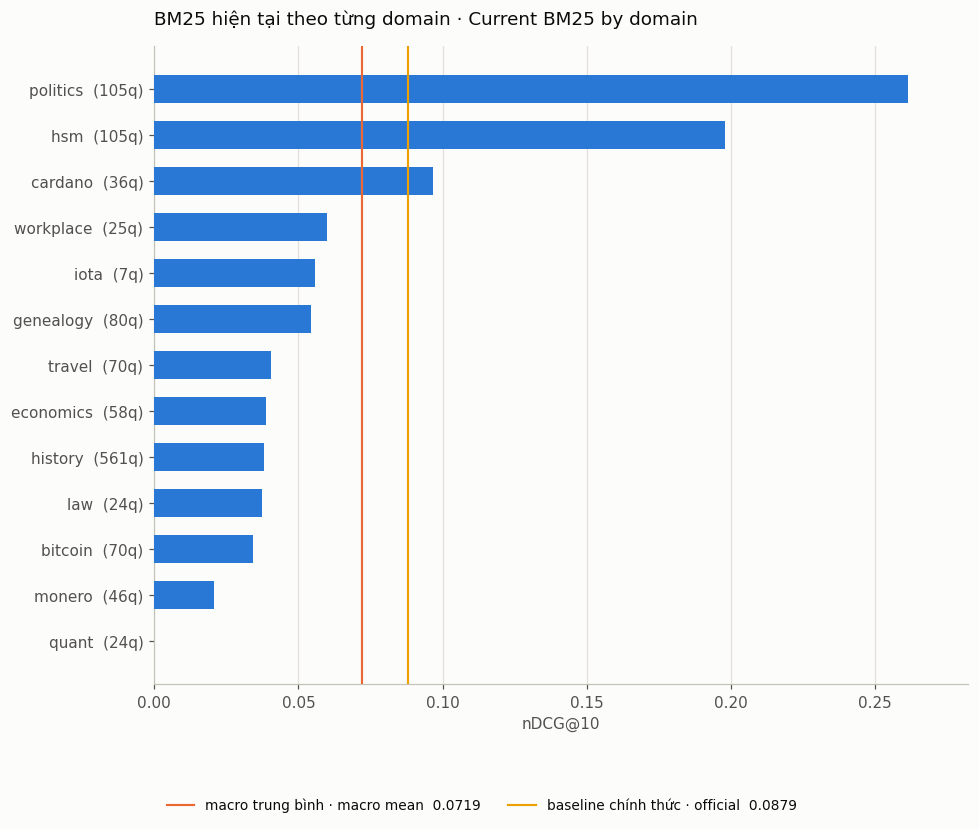

In [13]:
# --- Chart: where the baseline stands, domain by domain -------------------
rows = sorted(baseline.items(), key=lambda kv: kv[1]["metrics"]["nDCG@10"])
names  = [d for d, _ in rows]
scores = [v["metrics"]["nDCG@10"] for _, v in rows]
nq     = [v["metrics"]["num_topics"] for _, v in rows]

# The query count goes in the tick label, not as floating text: with 13 short
# bars and two reference lines, free-floating labels collide with the lines.
labels = [f"{d}  ({n}q)" for d, n in zip(names, nq)]
fig, ax = plt.subplots(figsize=(9, 0.42 * len(names) + 2.2))
ax.barh(labels, scores, height=0.62, color=SERIES[0], zorder=3)
ax.axvline(macro, color=SERIES[1], linewidth=1.4, zorder=4,
           label=f"macro trung bình · macro mean  {macro:.4f}")
ax.axvline(OFFICIAL_BM25_MACRO, color=SERIES[3], linewidth=1.4, zorder=4,
           label=f"baseline chính thức · official  {OFFICIAL_BM25_MACRO:.4f}")
style_axes(ax, xgrid=True, ygrid=False)
ax.set_xlabel("nDCG@10")
ax.set_title("BM25 hiện tại theo từng domain · Current BM25 by domain", loc="left")
# Legend below the plot: inside it would sit on top of the bars or the lines.
ax.legend(frameon=False, fontsize=9, ncol=2,
          loc="upper left", bbox_to_anchor=(0, -0.12 - 0.5 / len(names)))
ax.set_xlim(0, max(max(scores), OFFICIAL_BM25_MACRO) * 1.08)
# "(7q)" in each tick label is the query count: a 7-query domain carries a
# +/-0.43 confidence interval and cannot support a conclusion on its own.
plt.tight_layout(); plt.show()

---

# Phần C · Part C — Thí nghiệm 1: Tokenization
# Part C — Experiment 1: Tokenization

**VI** — Hệ thống hiện tại tokenize bằng đúng một dòng: `re.findall(r"[A-Za-z0-9]+", text.lower())`. Không rút gốc từ, không loại stopword. Baseline chính thức gần như chắc chắn dựng trên Lucene/Anserini, mà mặc định của Lucene là **lowercase + loại stopword + rút gốc Porter**. Đó là giả thuyết hàng đầu cho khoảng cách 22%.

Sáu biến thể được thử. Mỗi biến thể chỉ là một phép đánh số lại từ vựng trên **cùng một** ma trận đếm đã tokenize — nên toàn bộ sweep chỉ tốn thêm vài giây mỗi domain.

| Biến thể · Variant | Nội dung |
| --- | --- |
| `baseline` | như production: chỉ lowercase + tách `[A-Za-z0-9]+` |
| `stop_lucene` | + loại 33 stopword mặc định của Lucene |
| `stem` | + rút gốc Porter (không loại stopword) |
| `stop+stem` | + cả hai — **đây là mặc định của Anserini** |
| `stop+stem+html` | + loại thêm token cấu trúc HTML (`p`, `href`, `li`, …) |
| `aggressive` | + stopword mở rộng, bỏ token 1 ký tự |

**EN** — The production tokenizer does no stemming and no stopword removal; Lucene (and therefore almost certainly the official baseline) does both by default. Six variants are tested, each a relabelling of the same already-tokenized matrix.

> **Cảnh báo phải đọc kỹ · The warning that matters** — Cột `empty` đếm số truy vấn không trả về tài liệu nào. Scorer chính thức **loại** những truy vấn đó khỏi phép trung bình thay vì cho 0 điểm, nên một biến thể xoá quá tay có thể **trông tốt lên** chỉ vì nó âm thầm vứt đi các truy vấn khó nhất. Nếu `empty > 0`, điểm của biến thể đó không so sánh được.

In [14]:
TOKENIZER_VARIANTS = {
    "baseline":       dict(),
    "stop_lucene":    dict(stopwords=LUCENE_STOPWORDS),
    "stem":           dict(stem=True),
    "stop+stem":      dict(stopwords=LUCENE_STOPWORDS, stem=True),
    "stop+stem+html": dict(stopwords=LUCENE_STOPWORDS, stem=True, drop_html=True),
    "aggressive":     dict(stopwords=EXTENDED_STOPWORDS, stem=True,
                           drop_html=True, min_len=2),
}

def sweep_variants(variants, query_form="raw", domains=None, verbose=True):
    """Tokenize each domain ONCE, then evaluate every variant against it.

    `query_form` may be a single name or a list of names. Passing a list keeps
    them inside the same tokenization pass, which is the whole point: the pass
    is the expensive part, and re-paying it per query form would dominate the
    runtime of the interaction study below.

    Returns {variant: {domain: ...}} for a single form, or
            {(variant, form): {domain: ...}} for several.
    """
    domains = domains or DOMAINS_TO_RUN
    single = isinstance(query_form, str)
    form_names = [query_form] if single else list(query_form)
    out = {(v, f): {} for v in variants for f in form_names}

    for d in domains:
        f = domain_files(d)
        t0 = time.time()
        doc_ids, doc_texts = load_corpus(f["corpus"], MAX_DOCS_PER_DOMAIN)
        counts, terms = tokenize_corpus(doc_texts)
        del doc_texts; gc.collect()

        queries = load_queries(f["queries"])
        gold    = load_qrels(f["qrels"])
        periods = load_steps(f["steps"]) if f["steps"].is_file() else {}
        if verbose:
            print(f"  {d:<12} {len(doc_ids):>7,} docs, |V|={len(terms):>8,}  "
                  f"tokenized in {time.time()-t0:.0f}s", flush=True)

        for vname, kw in variants.items():
            t1 = time.time()
            cm, nt = build_vocab_map(terms, **kw)
            bm = BM25(doc_ids, remap_counts(counts, cm, len(nt)), nt)
            del cm; gc.collect()

            for fname in form_names:            # all forms share this index
                form = QUERY_FORMS[fname]
                run, empty = {}, 0
                for qid, q in queries:
                    hits = bm.search(apply_tokenizer(tokenize_raw(form(q)), **kw))
                    if hits:
                        run[qid] = [x for x, _ in hits]
                    else:
                        empty += 1
                m = score_domain(run, gold, periods)
                out[(vname, fname)][d] = {
                    "metrics": {k: v for k, v in m.items() if not k.startswith("per_query")},
                    "per_query_ndcg": m["per_query_ndcg"],
                    "per_query_recall": m["per_query_recall"],
                    "vocab": len(nt), "empty_results": empty,
                }
                if verbose:
                    flag = f"  !! {empty} empty" if empty else ""
                    tag = vname if single else f"{vname} / {fname}"
                    print(f"      {tag:<32} nDCG@10 {m['nDCG@10']:.4f}  "
                          f"R@100 {m['R@100']:.4f}  |V|={len(nt):>8,}  "
                          f"{time.time()-t1:>4.0f}s{flag}", flush=True)
            del bm; gc.collect()

        del counts, terms, doc_ids; gc.collect()
    if single:
        return {v: out[(v, form_names[0])] for v in variants}
    return out

t_start = time.time()
print(f"Tokenizer sweep: {len(TOKENIZER_VARIANTS)} variants x {len(DOMAINS_TO_RUN)} domains\n")
variant_results = sweep_variants(TOKENIZER_VARIANTS, query_form="raw")
print(f"\ntotal {time.time()-t_start:.0f}s")

with open(RESULTS_DIR / "C_tokenizers.json", "w", encoding="utf-8") as fh:
    json.dump(variant_results, fh, indent=2)

Tokenizer sweep: 6 variants x 13 domains

  bitcoin      153,291 docs, |V|= 733,888  tokenized in 31s
      baseline                         nDCG@10 0.0343  R@100 0.0921  |V|= 733,888     5s
      stop_lucene                      nDCG@10 0.0320  R@100 0.0945  |V|= 733,855     4s
      stem                             nDCG@10 0.0282  R@100 0.0862  |V|= 642,634    10s
      stop+stem                        nDCG@10 0.0284  R@100 0.0938  |V|= 642,632     4s
      stop+stem+html                   nDCG@10 0.0430  R@100 0.1390  |V|= 642,620     4s
      aggressive                       nDCG@10 0.0549  R@100 0.1724  |V|= 642,569     4s
  cardano       87,201 docs, |V|= 618,156  tokenized in 22s
      baseline                         nDCG@10 0.0965  R@100 0.3935  |V|= 618,156     3s
      stop_lucene                      nDCG@10 0.1220  R@100 0.4259  |V|= 618,123     2s
      stem                             nDCG@10 0.0784  R@100 0.3519  |V|= 532,995     4s
      stop+stem                      

In [15]:
# --- Pooled comparison with confidence intervals --------------------------
# Pooling every query from every domain is what brings the confidence interval
# down to a usable width. A per-domain comparison cannot separate these
# variants -- the intervals are wider than the differences.
def pool(results_for_variant, key="per_query_ndcg"):
    vals = []
    for d, r in results_for_variant.items():
        vals.extend(r[key].values())
    return vals

base_pool = pool(variant_results["baseline"])
summary = []
for vname, per_dom in variant_results.items():
    vals  = pool(per_dom)
    macro = float(np.mean([r["metrics"]["nDCG@10"] for r in per_dom.values()]))
    m, lo, hi = bootstrap_ci(vals)
    # Paired bootstrap on per-query differences: the right test here, because
    # both variants are scored on exactly the same queries, so the pairing
    # removes the (large) between-query variance that would otherwise swamp
    # a real effect.
    diffs = [per_dom[d]["per_query_ndcg"][q] - variant_results["baseline"][d]["per_query_ndcg"][q]
             for d, r in per_dom.items() for q in r["per_query_ndcg"]
             if q in variant_results["baseline"][d]["per_query_ndcg"]]
    dm, dlo, dhi = bootstrap_ci(diffs)
    summary.append({
        "variant": vname, "macro": macro, "pooled_mean": m, "lo": lo, "hi": hi,
        "delta": dm, "dlo": dlo, "dhi": dhi,
        "sig": (dlo > 0 or dhi < 0),
        "empty": sum(r["empty_results"] for r in per_dom.values()),
        "topics": sum(r["metrics"]["num_topics"] for r in per_dom.values()),
        "vocab": int(np.mean([r["vocab"] for r in per_dom.values()])),
    })

print(f"{'variant':<16}{'macro':>8}{'pooled':>8}{'95% CI':>18}"
      f"{'vs baseline':>14}{'sig?':>6}{'topics':>8}{'empty':>7}")
print("-" * 86)
for s in summary:
    ci = f"[{s['lo']:.4f},{s['hi']:.4f}]"
    dl = f"{s['delta']:+.4f}"
    print(f"{s['variant']:<16}{s['macro']:>8.4f}{s['pooled_mean']:>8.4f}{ci:>18}"
          f"{dl:>14}{('YES' if s['sig'] else 'no'):>6}"
          f"{s['topics']:>8}{s['empty']:>7}")

print(f"\nOfficial BM25 baseline: {OFFICIAL_BM25_MACRO:.4f}")
print("'sig?' = the paired 95% bootstrap interval on the per-query difference")
print("excludes zero, i.e. the change is larger than resampling noise.")
if any(s["empty"] for s in summary):
    print("\n[!] A variant produced empty results for some queries. Those queries are")
    print("    DROPPED by the official scorer, so that variant's score is inflated")
    print("    and not comparable. Treat it as invalid.")

variant            macro  pooled            95% CI   vs baseline  sig?  topics  empty
--------------------------------------------------------------------------------------
baseline          0.0719  0.0731   [0.0621,0.0839]       +0.0000    no    1211      0
stop_lucene       0.0763  0.0788   [0.0672,0.0896]       +0.0056   YES    1211      0
stem              0.0654  0.0641   [0.0538,0.0744]       -0.0090   YES    1211      0
stop+stem         0.0708  0.0690   [0.0581,0.0796]       -0.0041   YES    1211      0
stop+stem+html    0.0937  0.0951   [0.0830,0.1070]       +0.0220   YES    1211      0
aggressive        0.1154  0.1179   [0.1046,0.1308]       +0.0448   YES    1211      0

Official BM25 baseline: 0.0879
'sig?' = the paired 95% bootstrap interval on the per-query difference
excludes zero, i.e. the change is larger than resampling noise.


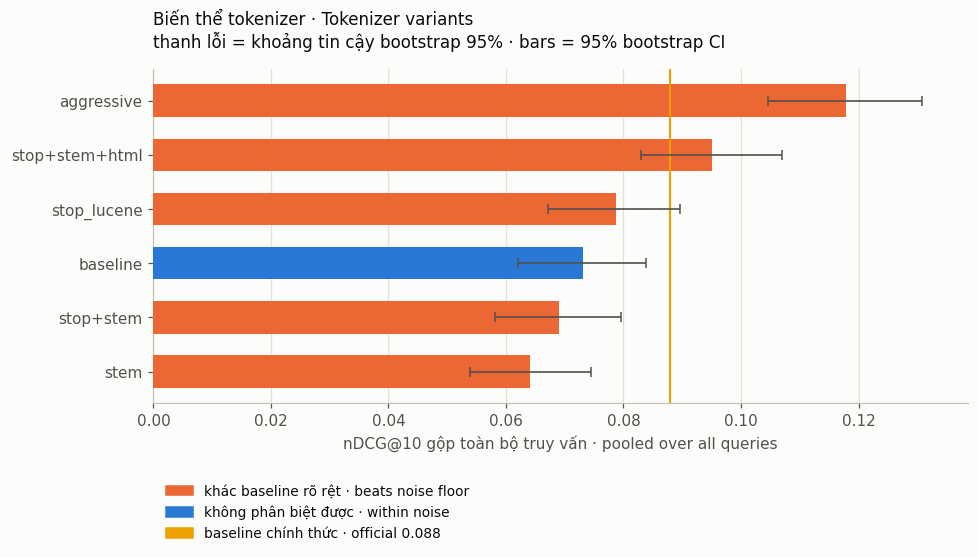

In [16]:
# --- Chart: tokenizer variants, pooled, with confidence intervals ---------
order = sorted(summary, key=lambda s: s["pooled_mean"])
names = [s["variant"] for s in order]
vals  = [s["pooled_mean"] for s in order]
err   = np.array([[s["pooled_mean"] - s["lo"] for s in order],
                  [s["hi"] - s["pooled_mean"] for s in order]])
# Colour carries meaning: blue = indistinguishable from baseline, orange =
# a difference larger than the noise floor. It is not a value ramp.
colors = [SERIES[1] if s["sig"] else SERIES[0] for s in order]

fig, ax = plt.subplots(figsize=(9, 0.5 * len(names) + 2.4))
ax.barh(names, vals, height=0.6, color=colors, zorder=3)
ax.errorbar(vals, range(len(names)), xerr=err, fmt="none",
            ecolor=INK_SOFT, elinewidth=1.1, capsize=3, zorder=5)
ax.axvline(OFFICIAL_BM25_MACRO, color=SERIES[3], linewidth=1.4, zorder=4,
           label=f"baseline chính thức · official  {OFFICIAL_BM25_MACRO:.4f}")
style_axes(ax, xgrid=True, ygrid=False)
ax.set_xlabel("nDCG@10 gộp toàn bộ truy vấn · pooled over all queries")
ax.set_title("Biến thể tokenizer · Tokenizer variants\n"
             "thanh lỗi = khoảng tin cậy bootstrap 95% · bars = 95% bootstrap CI",
             loc="left", fontsize=11)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=SERIES[1], label="khác baseline rõ rệt · beats noise floor"),
    Patch(color=SERIES[0], label="không phân biệt được · within noise"),
    Patch(color=SERIES[3], label=f"baseline chính thức · official {OFFICIAL_BM25_MACRO:.3f}"),
], frameon=False, fontsize=9, ncol=1,
   loc="upper left", bbox_to_anchor=(0, -0.14 - 0.4 / len(names)))
ax.set_xlim(0, max(max(vals) + err[1].max(), OFFICIAL_BM25_MACRO) * 1.06)
plt.tight_layout(); plt.show()

---

# Phần D · Part D — Thí nghiệm 2: Dạng truy vấn và trần recall
# Part D — Experiment 2: Query form and the recall ceiling

**VI** — **Trần recall là giới hạn cứng của toàn hệ thống.** Reranker chỉ sắp xếp lại những gì tầng một đã lấy được; nó không thể tạo ra tài liệu mà tầng một bỏ sót. Nếu R@100 là 12%, thì dù reranker hoàn hảo tuyệt đối, 88% tài liệu đúng vẫn nằm ngoài tầm với.

Đây là lý do phần này quan trọng hơn việc chọn model rerank: nó cho biết **đầu tư vào đâu mới có lãi**.

Phép đo trước đây trên 3 domain nhỏ gợi ý rằng dùng **riêng tiêu đề** làm recall tăng 2–3 lần. Nhưng 3 domain nhỏ nằm **dưới ngưỡng nhiễu** (±0,21 đến ±0,43) — con số đó chưa đủ tư cách làm kết luận. Phần này chạy lại trên **đủ 13 domain** và gộp per-query để có khoảng tin cậy thật.

**EN** — **The recall ceiling is a hard cap on the whole system.** A reranker reorders what the first stage found; it cannot conjure a document the first stage missed. An earlier 3-domain measurement suggested title-only doubles-to-triples recall, but 3 small domains sit *below the noise floor* (±0.21 to ±0.43), so that was never a conclusion. This runs all 13 domains and pools per-query.

In [17]:
# --- Sweep the four query forms, measuring the recall ceiling -------------
t_start = time.time()
form_results = {}
print(f"Query-form sweep: {len(QUERY_FORMS)} forms x {len(DOMAINS_TO_RUN)} domains")
print("(baseline tokenizer, so this isolates the query form)\n")

for d in DOMAINS_TO_RUN:
    f = domain_files(d)
    t0 = time.time()
    doc_ids, doc_texts = load_corpus(f["corpus"], MAX_DOCS_PER_DOMAIN)
    counts, terms = tokenize_corpus(doc_texts)
    del doc_texts; gc.collect()
    cm, nt = build_vocab_map(terms)
    bm = BM25(doc_ids, remap_counts(counts, cm, len(nt)), nt)
    del counts, cm, terms; gc.collect()

    queries = load_queries(f["queries"])
    gold    = load_qrels(f["qrels"])
    periods = load_steps(f["steps"]) if f["steps"].is_file() else {}
    print(f"  {d:<12} {len(doc_ids):>7,} docs  indexed in {time.time()-t0:.0f}s", flush=True)

    for fname, fn in QUERY_FORMS.items():
        run, empty = {}, 0
        for qid, q in queries:
            hits = bm.search(tokenize_raw(fn(q)))
            if hits:
                run[qid] = [x for x, _ in hits]
            else:
                empty += 1
        m = score_domain(run, gold, periods)
        form_results.setdefault(fname, {})[d] = {
            "metrics": {k: v for k, v in m.items() if not k.startswith("per_query")},
            "per_query_ndcg": m["per_query_ndcg"],
            "per_query_recall": m["per_query_recall"],
            "empty_results": empty,
        }
        print(f"      {fname:<15} nDCG@10 {m['nDCG@10']:.4f}   "
              f"R@10 {m['R@10']:.3f}  R@100 {m['R@100']:.3f}  R@1000 {m['R@1000']:.3f}"
              + (f"  !! {empty} empty" if empty else ""), flush=True)
    del bm, doc_ids, nt; gc.collect()

print(f"\ntotal {time.time()-t_start:.0f}s")
with open(RESULTS_DIR / "D_query_forms.json", "w", encoding="utf-8") as fh:
    json.dump(form_results, fh, indent=2)

Query-form sweep: 4 forms x 13 domains
(baseline tokenizer, so this isolates the query form)

  bitcoin      153,291 docs  indexed in 40s
      raw             nDCG@10 0.0343   R@10 0.046  R@100 0.092  R@1000 0.250
      stripped        nDCG@10 0.0421   R@10 0.057  R@100 0.140  R@1000 0.300
      title           nDCG@10 0.0840   R@10 0.104  R@100 0.201  R@1000 0.359
      title-weighted  nDCG@10 0.0699   R@10 0.080  R@100 0.176  R@1000 0.336
  cardano       87,201 docs  indexed in 25s
      raw             nDCG@10 0.0965   R@10 0.153  R@100 0.394  R@1000 0.636
      stripped        nDCG@10 0.1231   R@10 0.213  R@100 0.435  R@1000 0.702
      title           nDCG@10 0.1973   R@10 0.241  R@100 0.492  R@1000 0.723
      title-weighted  nDCG@10 0.1844   R@10 0.245  R@100 0.529  R@1000 0.765
  economics     93,756 docs  indexed in 21s
      raw             nDCG@10 0.0387   R@10 0.052  R@100 0.180  R@1000 0.519
      stripped        nDCG@10 0.0683   R@10 0.079  R@100 0.237  R@1000 0.555
    

In [18]:
# --- Pooled query-form comparison ----------------------------------------
def pool_recall(per_dom, k):
    out = []
    for d, r in per_dom.items():
        out.extend(v for v in r["per_query_recall"][f"R@{k}"].values() if v is not None)
    return out

print(f"{'query form':<16}{'nDCG@10':>10}{'95% CI':>18}"
      f"{'R@10':>9}{'R@100':>9}{'R@1000':>9}{'empty':>7}")
print("-" * 80)
form_summary = []
for fname in QUERY_FORMS:
    per_dom = form_results[fname]
    nd_vals = [v for d, r in per_dom.items() for v in r["per_query_ndcg"].values()]
    m, lo, hi = bootstrap_ci(nd_vals)
    rec = {k: float(np.mean(pool_recall(per_dom, k))) for k in RECALL_KS}
    empty = sum(r["empty_results"] for r in per_dom.values())
    form_summary.append({"form": fname, "ndcg": m, "lo": lo, "hi": hi,
                         **{f"R@{k}": rec[k] for k in RECALL_KS}, "empty": empty})
    print(f"{fname:<16}{m:>10.4f}{f'[{lo:.4f},{hi:.4f}]':>18}"
          f"{rec[10]:>9.4f}{rec[100]:>9.4f}{rec[1000]:>9.4f}{empty:>7}")

best = max(form_summary, key=lambda s: s["R@100"])
base = next(s for s in form_summary if s["form"] == "raw")
print(f"\nBest R@100: '{best['form']}' at {best['R@100']:.4f} "
      f"vs 'raw' at {base['R@100']:.4f}  ({best['R@100']/max(base['R@100'],1e-9):.2f}x)")
print(f"\nWhat this caps: even a PERFECT reranker over the top 100 could reach at")
print(f"most nDCG@10 bounded by R@100 = {best['R@100']:.1%} of gold being present.")

query form         nDCG@10            95% CI     R@10    R@100   R@1000  empty
--------------------------------------------------------------------------------
raw                 0.0731   [0.0621,0.0839]   0.0930   0.1995   0.3666      0
stripped            0.0929   [0.0808,0.1049]   0.1214   0.2402   0.4003      0
title               0.1332   [0.1189,0.1471]   0.1662   0.3382   0.5347      0
title-weighted      0.1148   [0.1016,0.1281]   0.1486   0.2876   0.4708      0

Best R@100: 'title' at 0.3382 vs 'raw' at 0.1995  (1.70x)

What this caps: even a PERFECT reranker over the top 100 could reach at
most nDCG@10 bounded by R@100 = 33.8% of gold being present.


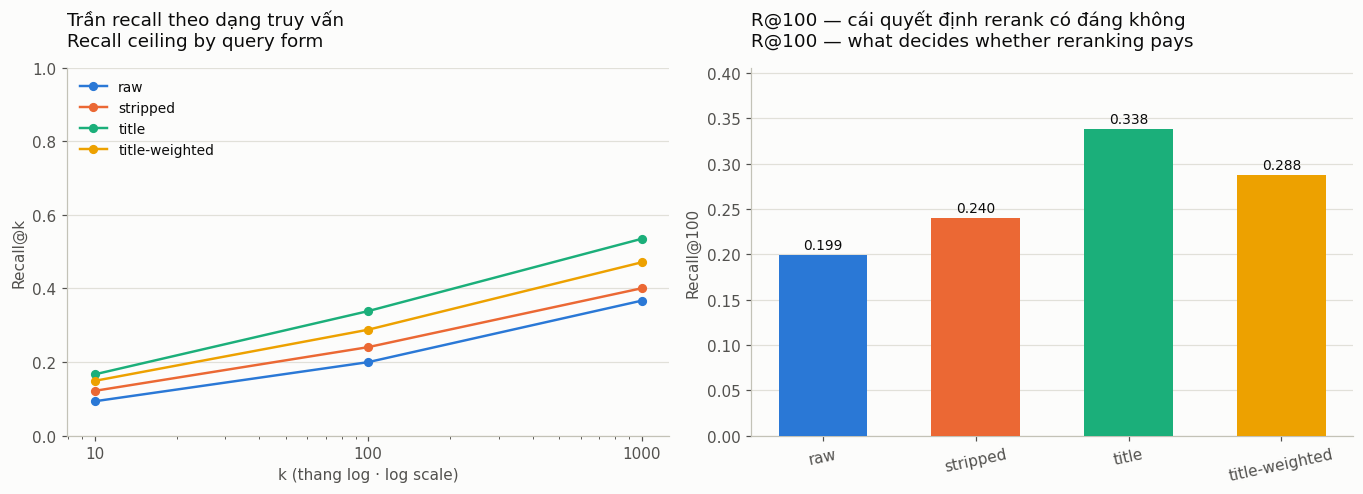

In [19]:
# --- Chart: the recall ceiling -------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax = axes[0]
ks = list(RECALL_KS)
for i, s in enumerate(form_summary):
    ax.plot(ks, [s[f"R@{k}"] for k in ks], marker="o", markersize=5,
            linewidth=1.6, color=SERIES[i], label=s["form"], zorder=3)
ax.set_xscale("log"); ax.set_xticks(ks); ax.set_xticklabels([str(k) for k in ks])
style_axes(ax)
ax.set_xlabel("k (thang log · log scale)"); ax.set_ylabel("Recall@k")
ax.set_ylim(0, 1)
ax.set_title("Trần recall theo dạng truy vấn\nRecall ceiling by query form", loc="left")
ax.legend(frameon=False, fontsize=9, loc="upper left")

ax = axes[1]
names = [s["form"] for s in form_summary]
vals  = [s["R@100"] for s in form_summary]
err   = None
ax.bar(names, vals, width=0.58, color=[SERIES[i] for i in range(len(names))], zorder=3)
style_axes(ax)
ax.set_ylabel("Recall@100")
ax.set_title("R@100 — cái quyết định rerank có đáng không\n"
             "R@100 — what decides whether reranking pays", loc="left")
for i, v in enumerate(vals):
    ax.text(i, v + max(vals) * 0.02, f"{v:.3f}", ha="center", fontsize=9, color=INK)
ax.set_ylim(0, max(vals) * 1.2)
ax.tick_params(axis="x", rotation=12)
plt.tight_layout(); plt.show()

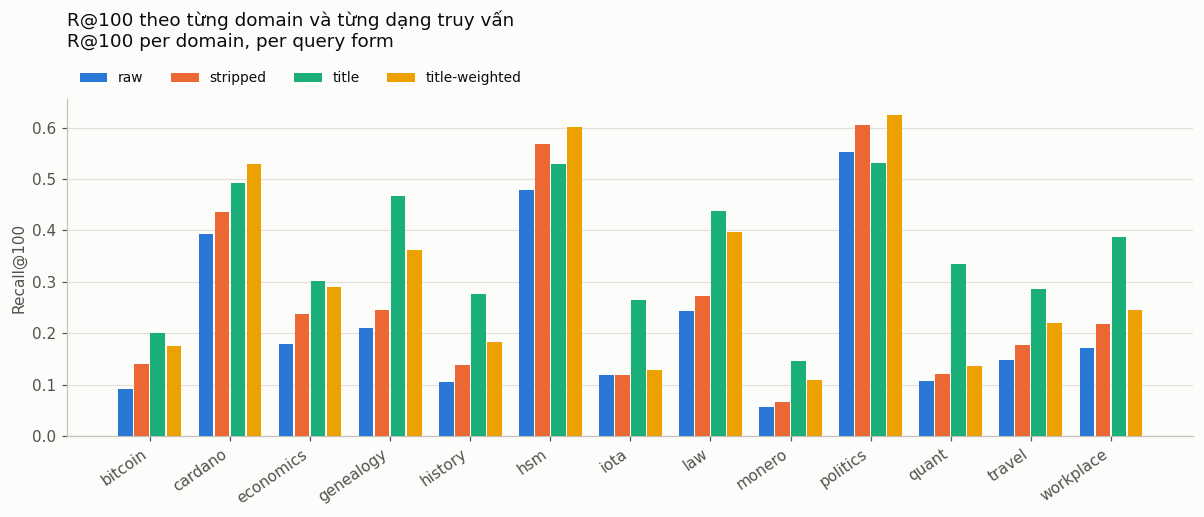

Domains won on R@100: {'title': 10, 'title-weighted': 3} (out of 13)


In [20]:
# --- Chart: does the query form help EVERY domain, or only on average? ----
# An average that hides 13 different directions is not a finding.
doms = DOMAINS_TO_RUN
x = np.arange(len(doms))
w = 0.8 / len(QUERY_FORMS)

fig, ax = plt.subplots(figsize=(max(9, 0.85 * len(doms)), 4.8))
for i, fname in enumerate(QUERY_FORMS):
    vals = [form_results[fname][d]["metrics"]["R@100"] for d in doms]
    ax.bar(x + i * w - 0.4 + w / 2, vals, width=w * 0.92,
           color=SERIES[i], label=fname, zorder=3)
style_axes(ax)
ax.set_xticks(x); ax.set_xticklabels(doms, rotation=35, ha="right")
ax.set_ylabel("Recall@100")
# Legend sits above the axes so a bar reaching 1.0 cannot run into it; the
# title is padded further up so the legend does not run into the title either.
ax.legend(frameon=False, fontsize=9, ncol=len(QUERY_FORMS),
          loc="lower left", bbox_to_anchor=(0, 1.005))
ax.set_title("R@100 theo từng domain và từng dạng truy vấn\n"
             "R@100 per domain, per query form", loc="left", pad=34)
plt.tight_layout(); plt.show()

# Count how many domains each form wins -- a consistent winner is a much
# stronger result than a better average.
wins = Counter()
for d in doms:
    wins[max(QUERY_FORMS, key=lambda f: form_results[f][d]["metrics"]["R@100"])] += 1
print("Domains won on R@100:", dict(wins), f"(out of {len(doms)})")

### D.1 — Tương tác giữa tokenizer và dạng truy vấn · The interaction

**VI** — Hai thí nghiệm trên **không độc lập với nhau**. Cả loại stopword lẫn gỡ HTML đều tấn công cùng một thứ: nhiễu trong truy vấn. Nếu chỉ cộng dồn kết quả tốt nhất của từng phần thì rất dễ đếm trùng cùng một lợi ích hai lần.

Ô dưới đo trực tiếp tổ hợp: hai tokenizer tốt nhất × hai dạng truy vấn tốt nhất.

**EN** — The two experiments are **not independent**: stopword removal and markup stripping both attack query noise, so adding up the best of each would double-count the same gain. This measures the combinations directly.

In [21]:
# --- Interaction: best tokenizers x best query forms ---------------------
top_tok  = [s["variant"] for s in sorted(summary, key=lambda s: -s["pooled_mean"])][:2]
top_form = [s["form"] for s in sorted(form_summary, key=lambda s: -s["ndcg"])][:2]
# Always include the production defaults as the control.
top_tok  = list(dict.fromkeys(top_tok + ["baseline"]))[:3]
top_form = list(dict.fromkeys(top_form + ["raw"]))[:3]
print(f"tokenizers: {top_tok}\nquery forms: {top_form}\n")

# Every combination is evaluated inside ONE tokenization pass per domain.
res = sweep_variants({t: TOKENIZER_VARIANTS[t] for t in top_tok},
                     query_form=top_form, verbose=False)
inter = {}
for (tname, fname), per_dom in res.items():
    vals = [v for d, r in per_dom.items() for v in r["per_query_ndcg"].values()]
    rec  = [v for d, r in per_dom.items()
            for v in r["per_query_recall"]["R@100"].values() if v is not None]
    m, lo, hi = bootstrap_ci(vals)
    inter[(tname, fname)] = {
        "ndcg": m, "lo": lo, "hi": hi, "R@100": float(np.mean(rec)),
        "empty": sum(r["empty_results"] for r in per_dom.values()),
        "macro": float(np.mean([r["metrics"]["nDCG@10"] for r in per_dom.values()])),
    }

print(f"\n{'tokenizer':<16}{'query form':<16}{'nDCG@10':>10}{'95% CI':>18}{'R@100':>9}{'empty':>7}")
print("-" * 76)
for (t, f), v in sorted(inter.items(), key=lambda kv: -kv[1]["ndcg"]):
    ci = "[{:.4f},{:.4f}]".format(v["lo"], v["hi"])
    print(f"{t:<16}{f:<16}{v['ndcg']:>10.4f}{ci:>18}{v['R@100']:>9.4f}{v['empty']:>7}")

with open(RESULTS_DIR / "D_interaction.json", "w", encoding="utf-8") as fh:
    json.dump({f"{t}|{f}": v for (t, f), v in inter.items()}, fh, indent=2)

tokenizers: ['aggressive', 'stop+stem+html', 'baseline']
query forms: ['title', 'title-weighted', 'raw']


tokenizer       query form         nDCG@10            95% CI    R@100  empty
----------------------------------------------------------------------------
aggressive      title               0.1458   [0.1321,0.1599]   0.3910      0
aggressive      title-weighted      0.1442   [0.1297,0.1585]   0.3799      0
stop+stem+html  title               0.1362   [0.1219,0.1500]   0.3548      0
baseline        title               0.1332   [0.1189,0.1471]   0.3382      0
stop+stem+html  title-weighted      0.1221   [0.1080,0.1353]   0.3114      0
aggressive      raw                 0.1179   [0.1046,0.1308]   0.3361      0
baseline        title-weighted      0.1148   [0.1016,0.1281]   0.2876      0
stop+stem+html  raw                 0.0951   [0.0830,0.1070]   0.2662      0
baseline        raw                 0.0731   [0.0621,0.0839]   0.1995      0


---

# Phần E · Part E — Thí nghiệm 3: Khử trùng lặp
# Part E — Experiment 3: Deduplication

**VI** — Corpus nằm trong **cache key** của embedding. Khử trùng lặp làm đổi số lượng tài liệu → đổi cache key → **phải encode lại toàn bộ trên GPU**. Vì thế đây là quyết định phải chốt *trước*, không phải sau.

Lý do muốn khử trùng lặp rất thực tế: trung vị 20,7% corpus là bản sao (riêng `bitcoin` là 50,0%). Bỏ chúng đi nghĩa là **encode ít tài liệu hơn hẳn** — tiết kiệm trực tiếp quota GPU — đồng thời làm sạch thống kê IDF.

## Cái bẫy · The trap

**VI** — Nhưng khử trùng lặp kiểu ngây thơ có thể **phá hỏng điểm số theo cách không hề báo lỗi**:

> Nếu tài liệu `A` và `B` có nội dung **giống hệt nhau**, và `qrels` chỉ đích danh `B`, mà ta lại giữ `A` — thì truy vấn đó **vĩnh viễn không thể đạt điểm**, dù hệ thống lấy đúng nội dung cần.

Không có lỗi nào được ném ra. File run vẫn hợp lệ. Điểm chỉ đơn giản là thấp hơn. Ô dưới đếm chính xác bao nhiêu cặp (truy vấn, gold) bị phá theo cách đó, rồi so ba chính sách.

**EN** — The corpus is part of the embedding cache key, so this decision must be made *before* spending GPU time. The upside is real (median 20.7% of each corpus is duplicated; `bitcoin` is 50.0%), but naive dedup **breaks scoring silently**: if `A` and `B` are textually identical and qrels names `B` while dedup keeps `A`, that query can never score — no error, a valid run file, just a lower number.

| Chính sách · Policy | Mô tả |
| --- | --- |
| `none` | không khử trùng lặp (đối chứng) |
| `keep_first` | giữ bản đầu tiên theo thứ tự corpus — bản ngây thơ, có bẫy |
| `keep_gold_aware` | *chẩn đoán, KHÔNG dùng được khi thi*: giữ đúng bản mà qrels chỉ tên. Chỉ để đo **trần trên** của việc khử trùng lặp. |
| `expand` | đánh chỉ mục bản đại diện, nhưng khi xuất kết quả thì trả **cả nhóm** vào các hạng liên tiếp — an toàn, đổi lại tốn chỗ trong top-k |

> **Lưu ý quan trọng · Important** — `keep_gold_aware` dùng nhãn đúng để chọn bản giữ lại, nên **không được phép dùng trong hệ thống dự thi**. Nó có mặt ở đây chỉ để trả lời một câu: *nếu chọn được hoàn hảo thì khử trùng lặp đáng giá bao nhiêu?* Nếu khoảng cách giữa `keep_first` và `keep_gold_aware` nhỏ, cái bẫy không đáng lo; nếu lớn, thì `expand` là lựa chọn bắt buộc.

In [22]:
_WS = re.compile(r"\s+")

def text_key(t):
    """Normalised text fingerprint. Whitespace and case are normalised so that
    cosmetic differences do not hide a genuine duplicate."""
    return hashlib.blake2b(_WS.sub(" ", (t or "")).strip().lower().encode("utf-8"),
                           digest_size=16).digest()

def duplicate_groups(doc_texts):
    groups = defaultdict(list)
    for i, t in enumerate(doc_texts):
        groups[text_key(t)].append(i)
    return groups

def analyse_duplicates(domain):
    f = domain_files(domain)
    doc_ids, doc_texts = load_corpus(f["corpus"], MAX_DOCS_PER_DOMAIN)
    gold = load_qrels(f["qrels"])
    groups = duplicate_groups(doc_texts)
    del doc_texts; gc.collect()

    id2i = {d: i for i, d in enumerate(doc_ids)}
    i2g  = {}
    for h, g in groups.items():
        for i in g:
            i2g[i] = h

    dup_groups = {h: g for h, g in groups.items() if len(g) > 1}
    n_dup_docs = sum(len(g) for g in dup_groups.values())

    all_gold = {d for s in gold.values() for d in s}
    present  = [d for d in all_gold if d in id2i]
    gold_in_dup = [d for d in present if len(groups[i2g[id2i[d]]]) > 1]

    # The trap, counted exactly: gold that keep-first would make unreachable.
    broken_pairs, broken_qs = 0, set()
    total_pairs = 0
    for qid, gs in gold.items():
        for d in gs:
            if d not in id2i:
                continue
            total_pairs += 1
            g = groups[i2g[id2i[d]]]
            if len(g) > 1 and id2i[d] != g[0]:
                broken_pairs += 1
                broken_qs.add(qid)

    out = {
        "n_docs": len(doc_ids), "n_distinct": len(groups),
        "n_dup_docs": n_dup_docs, "n_dup_groups": len(dup_groups),
        "dup_rate": n_dup_docs / max(len(doc_ids), 1),
        "shrink_rate": 1 - len(groups) / max(len(doc_ids), 1),
        "largest_group": max((len(g) for g in dup_groups.values()), default=1),
        "n_gold": len(present),
        "gold_in_dup": len(gold_in_dup),
        "gold_in_dup_rate": len(gold_in_dup) / max(len(present), 1),
        "broken_pairs": broken_pairs, "total_pairs": total_pairs,
        "broken_rate": broken_pairs / max(total_pairs, 1),
        "queries_affected": len(broken_qs), "n_queries": len(gold),
    }
    del doc_ids, groups, i2g, id2i; gc.collect()
    return out

print(f"{'domain':<12}{'docs':>9}{'distinct':>10}{'dup%':>7}{'shrink%':>9}"
      f"{'biggest':>9}{'gold in dup':>13}{'broken pairs':>14}{'queries hit':>13}")
print("-" * 96)
dup_stats = {}
for d in DOMAINS_TO_RUN:
    s = analyse_duplicates(d)
    dup_stats[d] = s
    print(f"{d:<12}{s['n_docs']:>9,}{s['n_distinct']:>10,}{s['dup_rate']*100:>6.1f}%"
          f"{s['shrink_rate']*100:>8.1f}%{s['largest_group']:>9,}"
          f"{s['gold_in_dup']:>7}/{s['n_gold']:<5}"
          f"{s['broken_pairs']:>8}/{s['total_pairs']:<5}"
          f"{s['queries_affected']:>7}/{s['n_queries']:<5}", flush=True)

tot_docs   = sum(s["n_docs"] for s in dup_stats.values())
tot_dist   = sum(s["n_distinct"] for s in dup_stats.values())
tot_broken = sum(s["broken_pairs"] for s in dup_stats.values())
tot_pairs  = sum(s["total_pairs"] for s in dup_stats.values())
tot_qhit   = sum(s["queries_affected"] for s in dup_stats.values())
tot_q      = sum(s["n_queries"] for s in dup_stats.values())
print("-" * 96)
print(f"{'TOTAL':<12}{tot_docs:>9,}{tot_dist:>10,}"
      f"{(1-tot_dist/tot_docs)*100:>6.1f}%{'':>9}{'':>9}"
      f"{'':>13}{tot_broken:>8}/{tot_pairs:<5}{tot_qhit:>7}/{tot_q:<5}")
print(f"\nCorpus would shrink from {tot_docs:,} to {tot_dist:,} documents "
      f"({(1-tot_dist/tot_docs)*100:.1f}% fewer to encode on the GPU).")
print(f"Naive keep-first dedup would silently break {tot_broken}/{tot_pairs} "
      f"({tot_broken/max(tot_pairs,1)*100:.1f}%) of (query, gold) pairs,")
print(f"affecting {tot_qhit}/{tot_q} queries.")

with open(RESULTS_DIR / "E_duplicates.json", "w", encoding="utf-8") as fh:
    json.dump(dup_stats, fh, indent=2)

domain           docs  distinct   dup%  shrink%  biggest  gold in dup  broken pairs  queries hit
------------------------------------------------------------------------------------------------
bitcoin       153,291    76,698  70.4%    50.0%      448     28/232        12/232       11/70   
cardano        87,201    47,509  67.7%    45.5%      460      1/80          0/80         0/36   
economics      93,756    74,687  32.1%    20.3%       50      4/203         1/203        1/58   
genealogy     156,228   136,100  20.0%    12.9%       42      6/233         3/233        3/80   
history       356,493   200,245  56.5%    43.8%      524     62/2546       35/2546      27/561  
hsm           213,818   169,547  31.3%    20.7%       60      0/252         0/252        0/105  
iota           10,372     9,680   9.4%     6.7%       92      2/29          1/29         1/7    
law            43,288    36,101  26.8%    16.6%       31      2/77          1/77         1/24   
monero         85,093    53,95

In [23]:
# --- The three policies, measured end to end -----------------------------
POLICIES = ["none", "keep_first", "keep_gold_aware", "expand"]

def dedup_domain(domain, policies=POLICIES):
    """Evaluate every dedup policy from ONE tokenization pass.

    The policies differ only in which DOCUMENTS survive, and a document is a
    row of the count matrix. So the corpus is tokenized once and each policy
    is a row selection -- rather than re-tokenizing the corpus four times,
    which on the full release would cost about twenty extra minutes for
    nothing.
    """
    f = domain_files(domain)
    doc_ids, doc_texts = load_corpus(f["corpus"], MAX_DOCS_PER_DOMAIN)
    gold    = load_qrels(f["qrels"])
    queries = load_queries(f["queries"])
    periods = load_steps(f["steps"]) if f["steps"].is_file() else {}

    groups = duplicate_groups(doc_texts)
    counts, terms = tokenize_corpus(doc_texts)
    del doc_texts; gc.collect()

    id2i = {d: i for i, d in enumerate(doc_ids)}
    all_gold = {d for s in gold.values() for d in s if d in id2i}

    results = {}
    for policy in policies:
        if policy == "none":
            keep_idx, expand_map = list(range(len(doc_ids))), None
        else:
            keep_idx, expand_map = [], {}
            for h, g in groups.items():
                if policy == "keep_gold_aware":
                    # Diagnostic upper bound only -- it reads the labels, so
                    # it is NOT a usable competition policy.
                    chosen = next((i for i in g if doc_ids[i] in all_gold), g[0])
                else:
                    chosen = g[0]
                keep_idx.append(chosen)
                if policy == "expand" and len(g) > 1:
                    expand_map[doc_ids[chosen]] = [doc_ids[i] for i in g]
            keep_idx.sort()

        kept_ids = [doc_ids[i] for i in keep_idx]
        sub = counts[keep_idx]                 # row selection, not re-tokenizing
        cm, nt = build_vocab_map(terms)
        bm = BM25(kept_ids, remap_counts(sub, cm, len(nt)), nt)
        del sub, cm; gc.collect()

        run = {}
        for qid, q in queries:
            hits = [d for d, _ in bm.search(tokenize_raw(q))]
            if policy == "expand" and expand_map:
                out, seen = [], set()
                for d in hits:
                    for mem in expand_map.get(d, [d]):
                        if mem not in seen:
                            seen.add(mem); out.append(mem)
                    if len(out) >= TOP_K:
                        break
                hits = out[:TOP_K]
            if hits:
                run[qid] = hits
        m = score_domain(run, gold, periods)
        results[policy] = (m, len(keep_idx))
        del bm, kept_ids, nt; gc.collect()

    del counts, terms, groups, doc_ids; gc.collect()
    return results

dedup_results = {p: {} for p in POLICIES}
print(f"{'domain':<12}" + "".join(f"{p:>18}" for p in POLICIES))
print("-" * (12 + 18 * len(POLICIES)))
for d in DOMAINS_TO_RUN:
    line = f"{d:<12}"
    for p, (m, n_kept) in dedup_domain(d).items():
        dedup_results[p][d] = {
            "metrics": {k: v for k, v in m.items() if not k.startswith("per_query")},
            "per_query_ndcg": m["per_query_ndcg"],
            "per_query_recall": m["per_query_recall"],
            "n_kept": n_kept,
        }
        line += f"{m['nDCG@10']:>10.4f}({n_kept//1000:>4}k)"
    print(line, flush=True)

with open(RESULTS_DIR / "E_policies.json", "w", encoding="utf-8") as fh:
    json.dump(dedup_results, fh, indent=2)

domain                    none        keep_first   keep_gold_aware            expand
------------------------------------------------------------------------------------
bitcoin         0.0343( 153k)    0.0494(  76k)    0.0494(  76k)    0.0396(  76k)
cardano         0.0965(  87k)    0.1535(  47k)    0.1535(  47k)    0.1359(  47k)
economics       0.0387(  93k)    0.0407(  74k)    0.0407(  74k)    0.0385(  74k)
genealogy       0.0545( 156k)    0.0666( 136k)    0.0666( 136k)    0.0623( 136k)
history         0.0379( 356k)    0.0333( 200k)    0.0333( 200k)    0.0317( 200k)
hsm             0.1980( 213k)    0.2178( 169k)    0.2178( 169k)    0.2042( 169k)
iota            0.0558(  10k)    0.1228(   9k)    0.1228(   9k)    0.1414(   9k)
law             0.0373(  43k)    0.0370(  36k)    0.0370(  36k)    0.0370(  36k)
monero          0.0207(  85k)    0.0259(  53k)    0.0259(  53k)    0.0259(  53k)
politics        0.2612( 183k)    0.2641( 135k)    0.2641( 135k)    0.2589( 135k)
quant           0.00

In [24]:
# --- Pooled dedup comparison ---------------------------------------------
print(f"{'policy':<18}{'macro':>9}{'pooled':>9}{'95% CI':>18}"
      f"{'vs none':>12}{'sig?':>6}{'R@100':>9}{'docs kept':>12}")
print("-" * 94)
none_pq = dedup_results["none"]
dedup_summary = []
for p in POLICIES:
    per_dom = dedup_results[p]
    vals = [v for d, r in per_dom.items() for v in r["per_query_ndcg"].values()]
    macro = float(np.mean([r["metrics"]["nDCG@10"] for r in per_dom.values()]))
    m, lo, hi = bootstrap_ci(vals)
    diffs = [per_dom[d]["per_query_ndcg"][q] - none_pq[d]["per_query_ndcg"][q]
             for d in per_dom for q in per_dom[d]["per_query_ndcg"]
             if q in none_pq[d]["per_query_ndcg"]]
    dm, dlo, dhi = bootstrap_ci(diffs)
    rec = float(np.mean([v for d, r in per_dom.items()
                         for v in r["per_query_recall"]["R@100"].values() if v is not None]))
    kept = sum(r["n_kept"] for r in per_dom.values())
    sig = (dlo > 0 or dhi < 0)
    dedup_summary.append({"policy": p, "macro": macro, "pooled": m, "lo": lo, "hi": hi,
                          "delta": dm, "sig": sig, "R@100": rec, "kept": kept})
    print(f"{p:<18}{macro:>9.4f}{m:>9.4f}{f'[{lo:.4f},{hi:.4f}]':>18}"
          f"{dm:>+12.4f}{('YES' if sig else 'no'):>6}{rec:>9.4f}{kept:>12,}")
print("\n'keep_gold_aware' uses the labels to pick which duplicate to keep.")
print("It is a DIAGNOSTIC UPPER BOUND, not a usable competition policy.")

policy                macro   pooled            95% CI     vs none  sig?    R@100   docs kept
----------------------------------------------------------------------------------------------
none                 0.0719   0.0731   [0.0621,0.0839]     +0.0000    no   0.1995   1,654,055
keep_first           0.0858   0.0771   [0.0657,0.0885]     +0.0040   YES   0.2241   1,167,099
keep_gold_aware      0.0858   0.0771   [0.0657,0.0885]     +0.0040   YES   0.2241   1,167,099
expand               0.0828   0.0733   [0.0621,0.0843]     +0.0002    no   0.2032   1,167,099

'keep_gold_aware' uses the labels to pick which duplicate to keep.
It is a DIAGNOSTIC UPPER BOUND, not a usable competition policy.


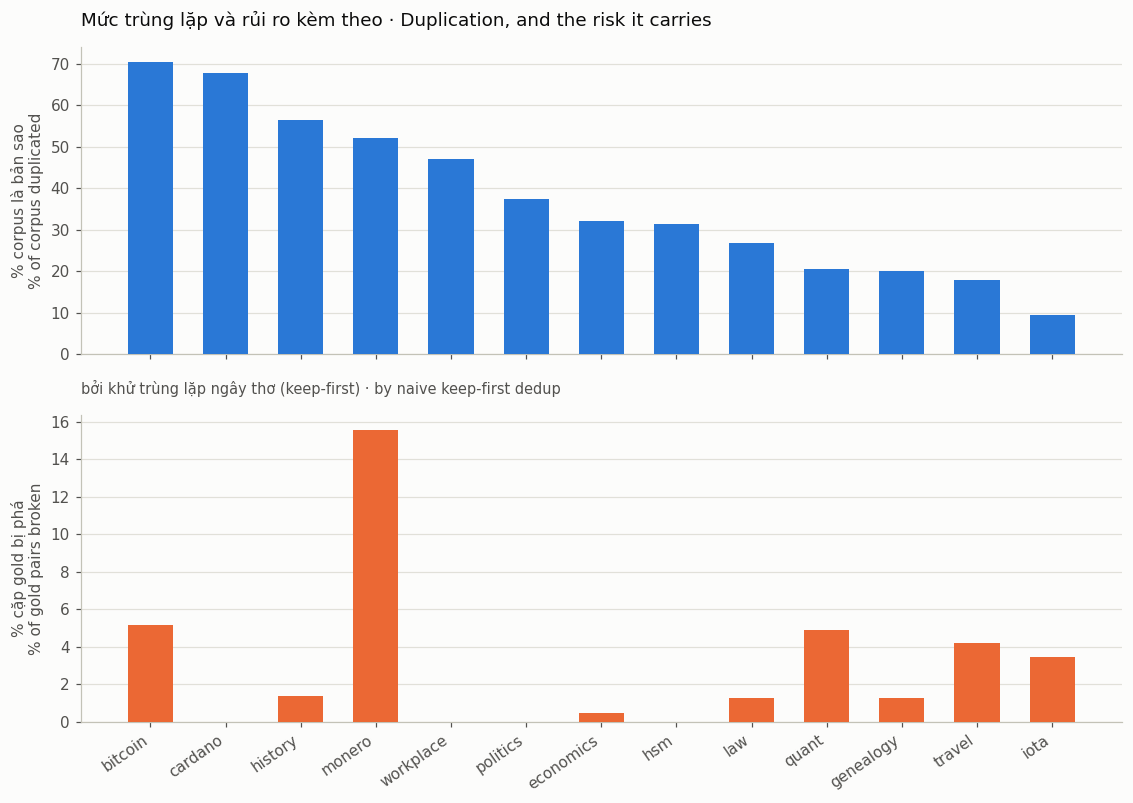

In [25]:
# --- Chart: duplication and the risk it carries, per domain --------------
doms = sorted(dup_stats, key=lambda d: -dup_stats[d]["dup_rate"])
x = np.arange(len(doms))

fig, axes = plt.subplots(2, 1, figsize=(max(9, 0.8 * len(doms)), 7.4), sharex=True)

ax = axes[0]
ax.bar(x, [dup_stats[d]["dup_rate"] * 100 for d in doms], width=0.6,
       color=SERIES[0], zorder=3)
style_axes(ax)
ax.set_ylabel("% corpus là bản sao\n% of corpus duplicated")
ax.set_title("Mức trùng lặp và rủi ro kèm theo · Duplication, and the risk it carries",
             loc="left")

ax = axes[1]
ax.bar(x, [dup_stats[d]["broken_rate"] * 100 for d in doms], width=0.6,
       color=SERIES[1], zorder=3)
style_axes(ax)
ax.set_ylabel("% cặp gold bị phá\n% of gold pairs broken")
ax.set_xticks(x); ax.set_xticklabels(doms, rotation=35, ha="right")
ax.set_xlabel("")
ax.set_title("bởi khử trùng lặp ngây thơ (keep-first) · by naive keep-first dedup",
             loc="left", fontsize=9.5, color=INK_SOFT)
plt.tight_layout(); plt.show()

---

# Phần F · Part F — Quyết định · Decisions

**VI** — Ô dưới tổng hợp toàn bộ số đo thành các quyết định cụ thể, và tách rõ hai loại: cái **phải chốt trước khi dùng GPU** (vì nằm trong cache key) và cái **sweep được sau, trên CPU**.

In [26]:
# --- Consolidated decisions ----------------------------------------------
best_tok  = max(summary,      key=lambda s: s["pooled_mean"])
best_form = max(form_summary, key=lambda s: s["ndcg"])
# The form with the best nDCG@10 is not necessarily the one with the best
# recall, and it is RECALL that caps what a reranker can ever reach. Both are
# reported, because they answer different questions.
best_recall_form = max(form_summary, key=lambda s: s["R@100"])
best_comb = max(inter.items(), key=lambda kv: kv[1]["ndcg"])
best_dedup_safe = max((s for s in dedup_summary if s["policy"] != "keep_gold_aware"),
                      key=lambda s: s["pooled"])
gold_aware = next(s for s in dedup_summary if s["policy"] == "keep_gold_aware")
none_pol   = next(s for s in dedup_summary if s["policy"] == "none")

W = 78
print("=" * W)
print("KẾT QUẢ ĐO ĐƯỢC · MEASURED RESULTS".center(W))
print("=" * W)


L = 34   # label column width
base_tok = next(s for s in summary if s["variant"] == "baseline")

print("\n1. TOKENIZATION")
print("   " + "baseline (production)".ljust(L) + f"{base_tok['pooled_mean']:.4f}")
print("   " + f"{best_tok['variant']} (best)".ljust(L) + f"{best_tok['pooled_mean']:.4f}"
      + f"  ({best_tok['delta']:+.4f}, "
      + ("significant" if best_tok["sig"] else "WITHIN NOISE") + ")")
print("   " + "official baseline".ljust(L) + f"{OFFICIAL_BM25_MACRO:.4f}")
_closed = best_tok["pooled_mean"] - base_tok["pooled_mean"]
_gap    = OFFICIAL_BM25_MACRO - base_tok["pooled_mean"]
if _gap > 0:
    print(f"   -> closes {_closed/_gap*100:.0f}% of the gap to the official baseline")

print("\n2. QUERY FORM / RECALL CEILING")
print("   " + f"{best_form['form']} (best nDCG)".ljust(L)
      + f"nDCG@10 {best_form['ndcg']:.4f}   R@100 {best_form['R@100']:.4f}")
print("   " + f"{best_recall_form['form']} (best recall)".ljust(L)
      + f"nDCG@10 {best_recall_form['ndcg']:.4f}   R@100 {best_recall_form['R@100']:.4f}")
print("   " + "raw (current)".ljust(L)
      + f"nDCG@10 {base['ndcg']:.4f}   R@100 {base['R@100']:.4f}")
# The ceiling is set by the best RECALL, not the best nDCG: recall is what
# bounds anything a reranker could do with the shortlist it is given.
_ceil = best_recall_form["R@100"]
print(f"   -> best case, gold is in the top 100 for {_ceil:.1%} of queries;")
print(f"      no reranker over that shortlist can reach the other {1-_ceil:.1%}.")
if best_form["form"] != best_recall_form["form"]:
    print(f"   NOTE: the best-nDCG form ({best_form['form']}) is NOT the best-recall")
    print(f"         form ({best_recall_form['form']}). If reranking is planned, tune")
    print( "         the first stage for RECALL, not for its own nDCG.")

print(f"\n3. BEST COMBINATION (measured, not added up)")
print(f"   tokenizer='{best_comb[0][0]}'  query_form='{best_comb[0][1]}'")
print(f"   nDCG@10 {best_comb[1]['ndcg']:.4f}  [{best_comb[1]['lo']:.4f},{best_comb[1]['hi']:.4f}]"
      f"   R@100 {best_comb[1]['R@100']:.4f}")

print(f"\n4. DEDUPLICATION")
print(f"   corpus {tot_docs:,} -> {tot_dist:,} docs ({(1-tot_dist/tot_docs)*100:.1f}% fewer to encode)")
print(f"   best SAFE policy '{best_dedup_safe['policy']}'  nDCG@10 {best_dedup_safe['pooled']:.4f} "
      f"({best_dedup_safe['delta']:+.4f} vs none, {'significant' if best_dedup_safe['sig'] else 'within noise'})")
print(f"   gold-aware upper bound            {gold_aware['pooled']:.4f}")
print(f"   naive keep-first silently breaks {tot_broken}/{tot_pairs} gold pairs "
      f"({tot_broken/max(tot_pairs,1)*100:.1f}%)")

print("\n" + "=" * W)
print("QUYẾT ĐỊNH · DECISIONS".center(W))
print("=" * W)
print("\nPHẢI CHỐT TRƯỚC KHI DÙNG GPU (nằm trong cache key)")
print("MUST BE FIXED BEFORE ANY GPU TIME (these are in the cache key)")
print(f"  [ ] corpus / dedup policy   -> measured winner: '{best_dedup_safe['policy']}'")
print( "  [ ] embedding model         -> NOT decided here (needs GPU to compare)")
print( "  [ ] document truncation     -> NOT decided here (needs GPU to compare)")
print( "  [ ] passage prefix          -> NOT decided here (model-dependent)")
print("\nSWEEPABLE LATER ON CPU (cache is reused)")
print(f"  [x] tokenizer               -> '{best_tok['variant']}'")
print(f"  [x] query form              -> '{best_form['form']}'")
print( "  [ ] fusion weights, rrf_k, pool_k, candidate_k, top_k")

print("\n" + "-" * W)
print("Reminder: the tokenizer and query form above apply to the LEXICAL stage.")
print("The dense stage has its own text handling; do not assume they transfer.")

                      KẾT QUẢ ĐO ĐƯỢC · MEASURED RESULTS                      

1. TOKENIZATION
   baseline (production)             0.0731
   aggressive (best)                 0.1179  (+0.0448, significant)
   official baseline                 0.0879
   -> closes 303% of the gap to the official baseline

2. QUERY FORM / RECALL CEILING
   title (best nDCG)                 nDCG@10 0.1332   R@100 0.3382
   title (best recall)               nDCG@10 0.1332   R@100 0.3382
   raw (current)                     nDCG@10 0.0731   R@100 0.1995
   -> best case, gold is in the top 100 for 33.8% of queries;
      no reranker over that shortlist can reach the other 66.2%.

3. BEST COMBINATION (measured, not added up)
   tokenizer='aggressive'  query_form='title'
   nDCG@10 0.1458  [0.1321,0.1599]   R@100 0.3910

4. DEDUPLICATION
   corpus 1,654,055 -> 1,167,099 docs (29.4% fewer to encode)
   best SAFE policy 'keep_first'  nDCG@10 0.0771 (+0.0040 vs none, significant)
   gold-aware upper bound       

---

## Việc tiếp theo · What happens next

**VI**

1. **Áp các thay đổi CPU vào `src/track1a/`.** Tokenizer thắng cuộc vào `retriever.py`; dạng truy vấn thắng cuộc thành mặc định của `--query-form`. Chạy lại Phần B để xác nhận macro nDCG@10 đã lên.
2. **Chốt chính sách khử trùng lặp**, vì nó nằm trong cache key. Nếu `expand` thắng, phần mở rộng nhóm phải nằm ở bước xuất kết quả, không nằm trong index.
3. **Chỉ khi đó mới động tới GPU**, và chỉ để encode corpus **một lần**. Sau khi có cache, mọi thứ còn lại — trọng số fusion, số ứng viên, model rerank, top-k — đều sweep được trên CPU.
4. **`dev` vẫn chưa được đụng tới.** Để dành đúng một lần chạy cuối.

**EN**

1. Apply the CPU-side winners to `src/track1a/`, then re-run Part B to confirm the macro went up.
2. Fix the dedup policy — it is in the cache key. If `expand` wins, the expansion belongs at output time, not in the index.
3. Only then spend GPU, and only to encode the corpus **once**. Everything after that sweeps on CPU.
4. `dev` remains untouched, reserved for a single final run.

> **Nhắc lại · Reminder** — Cấu trúc ID của bộ dữ liệu có rò rỉ thông tin (gold tập trung theo một dạng id nhất định). Phát hiện đó chỉ dùng để **ghi nhận trong báo cáo**, tuyệt đối **không** được đưa vào hệ thống dự thi. · The dataset's id structure leaks information. That finding is for the write-up only and must never enter the competition system.